In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
!pip install -q \
    neuralforecast \
    mlflow \
    dagshub \
    kaggle \
    pyarrow \
    scikit-learn \
    matplotlib \
    pandas \
    numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14

In [3]:
import os
import json
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import mlflow
import dagshub

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE, MSE

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch version: 2.11.0+cpu
CUDA available: False
Device: CPU


In [4]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [5]:
KAGGLE_DIR = Path.home() / ".kaggle"
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

uploaded_filename = next(iter(uploaded))

if uploaded_filename != "kaggle.json":
    raise ValueError(
        f"ატვირთული ფაილია '{uploaded_filename}'. საჭიროა kaggle.json."
    )

shutil.copy(uploaded_filename, KAGGLE_DIR / "kaggle.json")
os.chmod(KAGGLE_DIR / "kaggle.json", 0o600)

print("Kaggle credentials configured successfully.")

Kaggle credentials configured successfully.


In [6]:
!kaggle competitions files -c walmart-recruiting-store-sales-forecasting

name                            size  creationDate                
------------------------  ----------  --------------------------  
features.csv.zip              161700  2019-12-11 03:40:34.987000  
sampleSubmission.csv.zip      225538  2019-12-11 03:40:35.211000  
stores.csv                       532  2019-12-11 03:40:35.042000  
test.csv.zip                  240940  2019-12-11 03:40:35.042000  
train.csv.zip                2587161  2019-12-11 03:40:35.337000  


In [7]:
DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!kaggle competitions download \
    -c walmart-recruiting-store-sales-forecasting \
    -p /content/data

100% 2.70M/2.70M [00:01<00:00, 2.19MB/s]



In [8]:
import zipfile

zip_files = list(DATA_DIR.glob("*.zip"))

print("Found ZIP files:")
for file in zip_files:
    print("-", file.name)

for zip_path in zip_files:
    try:
        with zipfile.ZipFile(zip_path, "r") as archive:
            archive.extractall(DATA_DIR)
        print("Extracted:", zip_path.name)
    except zipfile.BadZipFile:
        print("Skipped non-standard archive:", zip_path.name)

Found ZIP files:
- walmart-recruiting-store-sales-forecasting.zip
Extracted: walmart-recruiting-store-sales-forecasting.zip


In [9]:
for path in sorted(DATA_DIR.iterdir()):
    print(path.name)

features.csv.zip
sampleSubmission.csv.zip
stores.csv
test.csv.zip
train.csv.zip
walmart-recruiting-store-sales-forecasting.zip


In [10]:
import zipfile
from pathlib import Path

DATA_DIR = Path("/content/data")

for zip_path in DATA_DIR.glob("*.zip"):
    try:
        with zipfile.ZipFile(zip_path, "r") as archive:
            archive.extractall(DATA_DIR)
        print("Extracted:", zip_path.name)
    except zipfile.BadZipFile:
        print("Skipped:", zip_path.name)

Extracted: test.csv.zip
Extracted: features.csv.zip
Extracted: sampleSubmission.csv.zip
Extracted: walmart-recruiting-store-sales-forecasting.zip
Extracted: train.csv.zip


In [11]:
for file in sorted(DATA_DIR.iterdir()):
    print(file.name)

features.csv
features.csv.zip
sampleSubmission.csv
sampleSubmission.csv.zip
stores.csv
test.csv
test.csv.zip
train.csv
train.csv.zip
walmart-recruiting-store-sales-forecasting.zip


In [12]:
import os
import pandas as pd

DATA_DIR = "/content/data"

train = pd.read_csv(
    os.path.join(DATA_DIR, "train.csv"),
    parse_dates=["Date"]
)

test = pd.read_csv(
    os.path.join(DATA_DIR, "test.csv"),
    parse_dates=["Date"]
)

features = pd.read_csv(
    os.path.join(DATA_DIR, "features.csv"),
    parse_dates=["Date"]
)

stores = pd.read_csv(
    os.path.join(DATA_DIR, "stores.csv")
)

sample_submission = pd.read_csv(
    os.path.join(DATA_DIR, "sampleSubmission.csv")
)

print("Train:", train.shape)
print("Test:", test.shape)
print("Features:", features.shape)
print("Stores:", stores.shape)
print("Sample submission:", sample_submission.shape)

Train: (421570, 5)
Test: (115064, 4)
Features: (8190, 12)
Stores: (45, 3)
Sample submission: (115064, 2)


In [13]:
datasets = {
    "train": train,
    "test": test,
    "features": features,
    "stores": stores,
    "sample_submission": sample_submission
}

for name, df in datasets.items():
    print(f"\n{'=' * 15} {name.upper()} {'=' * 15}")
    print("Columns:", df.columns.tolist())
    print(df.head())


=============== TRAIN ===============
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
   Store  Dept       Date  Weekly_Sales  IsHoliday
0      1     1 2010-02-05      24924.50      False
1      1     1 2010-02-12      46039.49       True
2      1     1 2010-02-19      41595.55      False
3      1     1 2010-02-26      19403.54      False
4      1     1 2010-03-05      21827.90      False

=============== TEST ===============
Columns: ['Store', 'Dept', 'Date', 'IsHoliday']
   Store  Dept       Date  IsHoliday
0      1     1 2012-11-02      False
1      1     1 2012-11-09      False
2      1     1 2012-11-16      False
3      1     1 2012-11-23       True
4      1     1 2012-11-30      False

=============== FEATURES ===============
Columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']
   Store       Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  \
0  

In [14]:
# Train მონაცემების გაერთიანება
train_merged = train.merge(
    features,
    on=["Store", "Date"],
    how="left",
    suffixes=("", "_features")
)

train_merged = train_merged.merge(
    stores,
    on="Store",
    how="left"
)

# Test მონაცემების გაერთიანება
test_merged = test.merge(
    features,
    on=["Store", "Date"],
    how="left",
    suffixes=("", "_features")
)

test_merged = test_merged.merge(
    stores,
    on="Store",
    how="left"
)

print("Train merged shape:", train_merged.shape)
print("Test merged shape:", test_merged.shape)

print("\nTrain columns:")
print(train_merged.columns.tolist())

Train merged shape: (421570, 17)
Test merged shape: (115064, 16)

Train columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_features', 'Type', 'Size']


In [15]:
# features ცხრილიდან მიღებული IsHoliday სვეტის შემოწმება
for df in [train_merged, test_merged]:
    if "IsHoliday_features" in df.columns:
        mismatch_count = (
            df["IsHoliday"] != df["IsHoliday_features"]
        ).sum()

        print("IsHoliday mismatch count:", mismatch_count)

        # ორიდან ერთს ვტოვებთ, რადგან ორივე ერთსა და იმავე ინფორმაციას შეიცავს
        df.drop(columns=["IsHoliday_features"], inplace=True)

print("\nTrain merged preview:")
display(train_merged.head())

print("\nTest merged preview:")
display(test_merged.head())

print("\nMissing values in train:")
display(
    train_merged.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing_Count")
)

IsHoliday mismatch count: 0
IsHoliday mismatch count: 0

Train merged preview:


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315



Test merged preview:


,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,A,151315



Missing values in train:


,Missing_Count
MarkDown2,310322
MarkDown4,286603
MarkDown3,284479
MarkDown1,270889
MarkDown5,270138
Store,0
Date,0
Dept,0
Fuel_Price,0
Temperature,0


In [16]:
# MarkDown სვეტებში NaN ნიშნავს, რომ კონკრეტული ფასდაკლება არ დაფიქსირებულა
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

train_merged[markdown_cols] = train_merged[markdown_cols].fillna(0)
test_merged[markdown_cols] = test_merged[markdown_cols].fillna(0)

# Test-ის ბოლო კვირებში CPI და Unemployment შესაძლოა აკლდეს.
# თითოეული მაღაზიის ფარგლებში წინა ცნობილი მნიშვნელობით ვავსებთ.
continuous_cols = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

combined_exog = pd.concat(
    [
        train_merged.assign(_dataset="train"),
        test_merged.assign(_dataset="test")
    ],
    ignore_index=True
).sort_values(["Store", "Date"])

combined_exog[continuous_cols] = (
    combined_exog
    .groupby("Store")[continuous_cols]
    .transform(lambda x: x.ffill().bfill())
)

train_merged = (
    combined_exog[combined_exog["_dataset"] == "train"]
    .drop(columns="_dataset")
    .reset_index(drop=True)
)

test_merged = (
    combined_exog[combined_exog["_dataset"] == "test"]
    .drop(columns=["_dataset", "Weekly_Sales"], errors="ignore")
    .reset_index(drop=True)
)

print("Missing values in train:", train_merged.isna().sum().sum())
print("Missing values in test:", test_merged.isna().sum().sum())

Missing values in train: 0
Missing values in test: 0


In [17]:
# თითოეული Store-Department წყვილი ცალკე დროითი სერიაა
train_merged["unique_id"] = (
    train_merged["Store"].astype(str)
    + "_"
    + train_merged["Dept"].astype(str)
)

test_merged["unique_id"] = (
    test_merged["Store"].astype(str)
    + "_"
    + test_merged["Dept"].astype(str)
)

# NeuralForecast-ის აუცილებელი ფორმატი:
# unique_id = სერიის იდენტიფიკატორი
# ds        = დრო
# y         = საპროგნოზო მნიშვნელობა
nf_train_df = (
    train_merged[
        ["unique_id", "Date", "Weekly_Sales"]
    ]
    .rename(
        columns={
            "Date": "ds",
            "Weekly_Sales": "y"
        }
    )
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

nf_test_df = (
    test_merged[
        ["unique_id", "Date"]
    ]
    .rename(columns={"Date": "ds"})
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

print("NeuralForecast train shape:", nf_train_df.shape)
print("NeuralForecast test shape:", nf_test_df.shape)
print("Number of time series:", nf_train_df["unique_id"].nunique())

display(nf_train_df.head())
display(nf_test_df.head())

NeuralForecast train shape: (421570, 3)
NeuralForecast test shape: (115064, 2)
Number of time series: 3331


,unique_id,ds,y
0,10_1,2010-02-05,40212.84
1,10_1,2010-02-12,67699.32
2,10_1,2010-02-19,49748.33
3,10_1,2010-02-26,33601.22
4,10_1,2010-03-05,36572.44


,unique_id,ds
0,10_1,2012-11-02
1,10_1,2012-11-09
2,10_1,2012-11-16
3,10_1,2012-11-23
4,10_1,2012-11-30


In [18]:
series_lengths = (
    nf_train_df
    .groupby("unique_id")
    .size()
    .reset_index(name="n_observations")
)

print(series_lengths["n_observations"].describe())

print("\nShortest series:")
display(series_lengths.sort_values("n_observations").head(20))

print("\nLongest series:")
display(
    series_lengths
    .sort_values("n_observations", ascending=False)
    .head(10)
)

count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
Name: n_observations, dtype: float64

Shortest series:


,unique_id,n_observations
647,18_39,1
656,18_48,1
2172,36_71,1
616,17_99,1
970,21_50,1
2193,36_99,1
2154,36_36,1
2148,36_29,1
3012,5_78,1
1002,21_96,1



Longest series:


,unique_id,n_observations
3328,9_96,143
3311,9_74,143
3310,9_72,143
3309,9_71,143
3308,9_7,143
3307,9_67,143
3305,9_6,143
3302,9_55,143
3300,9_52,143
3298,9_5,143


In [19]:
INPUT_SIZE = 52
VALIDATION_HORIZON = 40

MIN_REQUIRED_LENGTH = INPUT_SIZE + VALIDATION_HORIZON

valid_series_ids = series_lengths.loc[
    series_lengths["n_observations"] >= MIN_REQUIRED_LENGTH,
    "unique_id"
]

nf_train_filtered = (
    nf_train_df[
        nf_train_df["unique_id"].isin(valid_series_ids)
    ]
    .copy()
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

removed_series = (
    nf_train_df["unique_id"].nunique()
    - nf_train_filtered["unique_id"].nunique()
)

print("Minimum required length:", MIN_REQUIRED_LENGTH)
print("Original series:", nf_train_df["unique_id"].nunique())
print("Valid series:", nf_train_filtered["unique_id"].nunique())
print("Removed short series:", removed_series)
print("Filtered rows:", nf_train_filtered.shape)

Minimum required length: 92
Original series: 3331
Valid series: 2895
Removed short series: 436
Filtered rows: (409614, 3)


In [20]:
# თითოეული სერიის სტატისტიკის დათვლა
series_quality = (
    nf_train_df
    .sort_values(["unique_id", "ds"])
    .groupby("unique_id")
    .agg(
        n_observations=("ds", "size"),
        n_unique_dates=("ds", "nunique"),
        first_date=("ds", "min"),
        last_date=("ds", "max"),
        zero_sales_count=("y", lambda x: (x == 0).sum()),
        negative_sales_count=("y", lambda x: (x < 0).sum()),
        mean_sales=("y", "mean"),
        std_sales=("y", "std")
    )
    .reset_index()
)

# თეორიულად რამდენი კვირა უნდა იყოს პირველ და ბოლო თარიღს შორის
series_quality["expected_weeks"] = (
    (series_quality["last_date"] - series_quality["first_date"]).dt.days // 7
) + 1

series_quality["missing_weeks"] = (
    series_quality["expected_weeks"]
    - series_quality["n_unique_dates"]
)

series_quality["duplicate_dates"] = (
    series_quality["n_observations"]
    - series_quality["n_unique_dates"]
)

series_quality["zero_sales_ratio"] = (
    series_quality["zero_sales_count"]
    / series_quality["n_observations"]
)

print("Series with missing weeks:",
      (series_quality["missing_weeks"] > 0).sum())

print("Series with duplicated dates:",
      (series_quality["duplicate_dates"] > 0).sum())

print("Series with negative sales:",
      (series_quality["negative_sales_count"] > 0).sum())

print("Series with over 80% zero sales:",
      (series_quality["zero_sales_ratio"] >= 0.80).sum())

display(
    series_quality.sort_values(
        ["missing_weeks", "duplicate_dates"],
        ascending=False
    ).head(20)
)

Series with missing weeks: 605
Series with duplicated dates: 0
Series with negative sales: 376
Series with over 80% zero sales: 0


,unique_id,n_observations,n_unique_dates,first_date,last_date,zero_sales_count,negative_sales_count,mean_sales,std_sales,expected_weeks,missing_weeks,duplicate_dates,zero_sales_ratio
2112,35_78,5,5,2010-02-05,2012-09-07,0,0,12.600000,11.058933,136,131,0,0.000000
2280,38_34,14,14,2010-02-05,2012-10-26,0,0,12.672857,12.178894,143,129,0,0.000000
1043,22_47,12,12,2010-02-19,2012-10-12,0,6,19.260000,138.402668,139,127,0,0.000000
2698,43_26,15,15,2010-02-05,2012-10-19,0,2,4.463333,6.598283,142,127,0,0.000000
2275,38_29,12,12,2010-03-12,2012-10-26,0,0,14.739167,9.180174,138,126,0,0.000000
2771,44_44,10,10,2010-03-12,2012-10-12,0,3,4.743000,16.316532,136,126,0,0.000000
1762,30_99,11,11,2010-02-05,2012-09-07,0,2,-0.641818,2.021884,136,125,0,0.000000
2017,34_47,12,12,2010-02-19,2012-09-28,0,7,-78.919167,278.526803,137,125,0,0.000000
2291,38_55,8,8,2010-04-09,2012-10-12,0,1,9.412500,30.386408,132,124,0,0.000000
135,11_78,6,6,2010-02-05,2012-07-20,0,0,10.833333,7.960318,129,123,0,0.000000


In [21]:
train_series_ids = set(nf_train_df["unique_id"].unique())
test_series_ids = set(nf_test_df["unique_id"].unique())
dlinear_series_ids = set(valid_series_ids)

# Test-ში არსებული სერიები, რომლებზეც DLinear შეგვიძლია გამოვიყენოთ
dlinear_test_ids = test_series_ids.intersection(dlinear_series_ids)

# Test-ში არსებული მოკლე სერიები — მათთვის fallback დაგვჭირდება
fallback_test_ids = test_series_ids - dlinear_series_ids

# Test-ში არსებული სერიები, რომლებიც Train-ში საერთოდ არ ყოფილა
unseen_test_ids = test_series_ids - train_series_ids

# Train-ში არსებული სერიები, რომლებიც Test-ში აღარ გვხვდება
train_only_ids = train_series_ids - test_series_ids

print("Train series:", len(train_series_ids))
print("Test series:", len(test_series_ids))
print("DLinear-compatible Test series:", len(dlinear_test_ids))
print("Fallback Test series:", len(fallback_test_ids))
print("Completely unseen Test series:", len(unseen_test_ids))
print("Train-only series:", len(train_only_ids))

# ყველა Test სტრიქონისთვის პროგნოზის მეთოდის მინიჭება
test_strategy = nf_test_df.copy()

test_strategy["forecast_method"] = test_strategy["unique_id"].apply(
    lambda uid: (
        "DLinear"
        if uid in dlinear_test_ids
        else "Fallback"
        if uid in train_series_ids
        else "Global_Fallback"
    )
)

print("\nTest rows by forecast method:")
display(
    test_strategy["forecast_method"]
    .value_counts()
    .rename_axis("forecast_method")
    .reset_index(name="test_rows")
)

assert len(test_strategy) == len(nf_test_df)
assert test_strategy["forecast_method"].isna().sum() == 0

Train series: 3331
Test series: 3169
DLinear-compatible Test series: 2895
Fallback Test series: 274
Completely unseen Test series: 11
Train-only series: 173

Test rows by forecast method:


,forecast_method,test_rows
0,DLinear,111317
1,Fallback,3711
2,Global_Fallback,36


In [22]:
import pandas as pd

INPUT_SIZE = 52
VALIDATION_HORIZON = 40
REQUIRED_TAIL = INPUT_SIZE + VALIDATION_HORIZON

global_last_date = nf_train_df["ds"].max()
required_dates = pd.date_range(
    end=global_last_date,
    periods=REQUIRED_TAIL,
    freq="W-FRI"
)

def check_recent_history(group):
    observed_dates = set(group["ds"])

    available_tail_dates = sum(
        date in observed_dates
        for date in required_dates
    )

    return pd.Series({
        "n_observations": len(group),
        "last_date": group["ds"].max(),
        "recent_weeks_available": available_tail_dates,
        "recent_weeks_missing": REQUIRED_TAIL - available_tail_dates,
        "ends_at_global_last_date":
            group["ds"].max() == global_last_date
    })

recent_history_check = (
    nf_train_df
    .groupby("unique_id")
    .apply(check_recent_history)
    .reset_index()
)

strict_dlinear_ids = recent_history_check.loc[
    (recent_history_check["recent_weeks_missing"] == 0)
    & (recent_history_check["ends_at_global_last_date"]),
    "unique_id"
]

print("Global last training date:", global_last_date)
print("Required continuous recent weeks:", REQUIRED_TAIL)
print("Previously length-valid series:", len(valid_series_ids))
print("Strictly DLinear-compatible series:", len(strict_dlinear_ids))

print("\nSeries missing recent weeks:")
display(
    recent_history_check
    .sort_values(
        ["recent_weeks_missing", "last_date"],
        ascending=[False, True]
    )
    .head(20)
)

Global last training date: 2012-10-26 00:00:00
Required continuous recent weeks: 92
Previously length-valid series: 2895
Strictly DLinear-compatible series: 2697

Series missing recent weeks:


,unique_id,n_observations,last_date,recent_weeks_available,recent_weeks_missing,ends_at_global_last_date
2037,34_78,1,2010-02-05,0,92,False
343,14_43,1,2010-02-12,0,92,False
2181,36_85,2,2010-02-12,0,92,False
656,18_48,1,2010-02-19,0,92,False
3012,5_78,1,2010-02-26,0,92,False
3299,9_51,3,2010-03-05,0,92,False
1940,33_36,4,2010-03-12,0,92,False
1958,33_71,1,2010-03-12,0,92,False
1652,2_39,4,2010-03-19,0,92,False
2448,3_78,1,2010-04-02,0,92,False


In [23]:
strict_dlinear_ids = set(strict_dlinear_ids)
train_series_ids = set(nf_train_df["unique_id"].unique())
test_series_ids = set(nf_test_df["unique_id"].unique())

# DLinear მხოლოდ სრულ და უწყვეტ სერიებზე
dlinear_test_ids = test_series_ids.intersection(strict_dlinear_ids)

# Train-ში არსებობს, მაგრამ DLinear-ისთვის არასაკმარისია
fallback_test_ids = (
    test_series_ids.intersection(train_series_ids)
    - strict_dlinear_ids
)

# Test-ში არის, Train-ში საერთოდ არ ყოფილა
unseen_test_ids = test_series_ids - train_series_ids

nf_train_dlinear = (
    nf_train_df[
        nf_train_df["unique_id"].isin(strict_dlinear_ids)
    ]
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

test_strategy = nf_test_df.copy()

def assign_method(unique_id):
    if unique_id in dlinear_test_ids:
        return "DLinear"
    elif unique_id in fallback_test_ids:
        return "Fallback"
    return "Global_Fallback"

test_strategy["forecast_method"] = (
    test_strategy["unique_id"].map(assign_method)
)

print("DLinear training series:", len(strict_dlinear_ids))
print("DLinear training rows:", len(nf_train_dlinear))
print("DLinear Test series:", len(dlinear_test_ids))
print("Fallback Test series:", len(fallback_test_ids))
print("Completely unseen Test series:", len(unseen_test_ids))

print("\nTest rows by forecast method:")
display(
    test_strategy
    .groupby("forecast_method")
    .agg(
        test_rows=("unique_id", "size"),
        series_count=("unique_id", "nunique")
    )
    .reset_index()
)

assert len(test_strategy) == len(nf_test_df)
assert test_strategy["forecast_method"].isna().sum() == 0

DLinear training series: 2697
DLinear training rows: 385121
DLinear Test series: 2697
Fallback Test series: 461
Completely unseen Test series: 11

Test rows by forecast method:


,forecast_method,test_rows,series_count
0,DLinear,105078,2697
1,Fallback,9950,461
2,Global_Fallback,36,11


In [24]:
import numpy as np
import pandas as pd

VALIDATION_HORIZON = 40

# ორიგინალ train-ში თარიღის ფორმატის გასწორება
train["Date"] = pd.to_datetime(train["Date"])

# Holiday ინფორმაციის ცალკე ცხრილი
holiday_lookup = train[["Store", "Dept", "Date", "IsHoliday"]].copy()

holiday_lookup["unique_id"] = (
    holiday_lookup["Store"].astype(str)
    + "_"
    + holiday_lookup["Dept"].astype(str)
)

holiday_lookup = (
    holiday_lookup[["unique_id", "Date", "IsHoliday"]]
    .rename(columns={"Date": "ds"})
    .drop_duplicates(["unique_id", "ds"])
)

# მხოლოდ DLinear-ისთვის ვარგისი სერიები
validation_base = (
    nf_train_dlinear
    .sort_values(["unique_id", "ds"])
    .copy()
)

# თითოეულ სერიაში რიგის ნომერი ბოლოდან
validation_base["position_from_end"] = (
    validation_base
    .groupby("unique_id")
    .cumcount(ascending=False)
)

# ბოლო 40 კვირა validation, დანარჩენი train
train_split = (
    validation_base[
        validation_base["position_from_end"] >= VALIDATION_HORIZON
    ]
    .drop(columns="position_from_end")
    .reset_index(drop=True)
)

validation_split = (
    validation_base[
        validation_base["position_from_end"] < VALIDATION_HORIZON
    ]
    .drop(columns="position_from_end")
    .merge(
        holiday_lookup,
        on=["unique_id", "ds"],
        how="left",
        validate="one_to_one"
    )
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

# Kaggle-ის წონები
validation_split["weight"] = np.where(
    validation_split["IsHoliday"].fillna(False),
    5.0,
    1.0
)

# Leakage-ის შემოწმება
train_last_dates = (
    train_split.groupby("unique_id")["ds"]
    .max()
    .rename("train_last_date")
)

validation_first_dates = (
    validation_split.groupby("unique_id")["ds"]
    .min()
    .rename("validation_first_date")
)

leakage_check = pd.concat(
    [train_last_dates, validation_first_dates],
    axis=1
)

assert (
    leakage_check["train_last_date"]
    < leakage_check["validation_first_date"]
).all(), "Data leakage detected!"

assert validation_split["IsHoliday"].isna().sum() == 0
assert validation_split.groupby("unique_id").size().eq(40).all()
assert len(train_split) + len(validation_split) == len(nf_train_dlinear)

print("Training rows:", len(train_split))
print("Validation rows:", len(validation_split))
print("Validation series:", validation_split["unique_id"].nunique())
print("Validation weeks per series:",
      validation_split.groupby("unique_id").size().unique())

print("Holiday validation rows:",
      validation_split["IsHoliday"].sum())

print("Train ends before validation:",
      (
          leakage_check["train_last_date"]
          < leakage_check["validation_first_date"]
      ).all())

display(validation_split.head())

Training rows: 277241
Validation rows: 107880
Validation series: 2697
Validation weeks per series: [40]
Holiday validation rows: 5394
Train ends before validation: True


,unique_id,ds,y,IsHoliday,weight
0,10_1,2012-01-27,32559.13,False,1.0
1,10_1,2012-02-03,36444.00,False,1.0
2,10_1,2012-02-10,50434.11,True,5.0
3,10_1,2012-02-17,74930.33,False,1.0
4,10_1,2012-02-24,28751.57,False,1.0


In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def calculate_metrics(y_true, y_pred, weights):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weights = np.asarray(weights)

    return {
        "WMAE": np.sum(weights * np.abs(y_true - y_pred))
                / np.sum(weights),

        "MAE": mean_absolute_error(y_true, y_pred),

        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),

        "R2": r2_score(y_true, y_pred)
    }


# სრული ისტორია გვჭირდება Seasonal Naive-ისთვის
baseline_df = (
    nf_train_dlinear
    .sort_values(["unique_id", "ds"])
    .copy()
)

# Seasonal Naive: ზუსტად 52 კვირის წინანდელი გაყიდვა
baseline_df["SeasonalNaive52"] = (
    baseline_df
    .groupby("unique_id")["y"]
    .shift(52)
)

# ბოლო 40 კვირის ამოღება
baseline_validation = (
    baseline_df
    .groupby("unique_id", group_keys=False)
    .tail(VALIDATION_HORIZON)
    .merge(
        validation_split[
            ["unique_id", "ds", "weight", "IsHoliday"]
        ],
        on=["unique_id", "ds"],
        how="left",
        validate="one_to_one"
    )
)

# თითოეული სერიის training ნაწილის ბოლო მნიშვნელობა
last_value_predictions = (
    train_split
    .groupby("unique_id")["y"]
    .last()
    .rename("LastValue")
)

# ბოლო 4 კვირის საშუალო
mean4_predictions = (
    train_split
    .groupby("unique_id")["y"]
    .apply(lambda x: x.tail(4).mean())
    .rename("Mean4")
)

baseline_validation = (
    baseline_validation
    .merge(
        last_value_predictions,
        on="unique_id",
        how="left"
    )
    .merge(
        mean4_predictions,
        on="unique_id",
        how="left"
    )
)

prediction_columns = [
    "LastValue",
    "Mean4",
    "SeasonalNaive52"
]

assert baseline_validation[prediction_columns].isna().sum().sum() == 0
assert len(baseline_validation) == len(validation_split)

baseline_results = []

for model_name in prediction_columns:
    metrics = calculate_metrics(
        y_true=baseline_validation["y"],
        y_pred=baseline_validation[model_name],
        weights=baseline_validation["weight"]
    )

    baseline_results.append({
        "Model": model_name,
        **metrics
    })

baseline_results = (
    pd.DataFrame(baseline_results)
    .sort_values("WMAE")
    .reset_index(drop=True)
)

print("Baseline comparison — lower WMAE is better:")
display(baseline_results)

best_baseline = baseline_results.iloc[0]

print("\nBest baseline:", best_baseline["Model"])
print("Best baseline WMAE:",
      round(best_baseline["WMAE"], 4))

Baseline comparison — lower WMAE is better:


,Model,WMAE,MAE,RMSE,R2
0,SeasonalNaive52,1916.069937,1908.880886,3976.139172,0.969191
1,Mean4,2879.128510,2844.758948,5797.804170,0.934493
2,LastValue,3018.140694,2973.143788,6052.732662,0.928606



Best baseline: SeasonalNaive52
Best baseline WMAE: 1916.0699


In [26]:
import torch

from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE

# შედეგის გამეორებადობისთვის
torch.manual_seed(42)
np.random.seed(42)

HORIZON = 40
INPUT_SIZE = 52

dlinear_model = DLinear(
    h=HORIZON,
    input_size=INPUT_SIZE,

    # ტრენინგის მიზნობრივი ფუნქცია
    loss=MAE(),

    # პირველი საბაზისო ექსპერიმენტის პარამეტრები
    max_steps=500,
    learning_rate=1e-3,
    batch_size=64,
    windows_batch_size=1024,

    # თითოეული სერიის მასშტაბის სტაბილიზაცია
    scaler_type="robust",

    # სწავლების მონიტორინგი
    val_check_steps=50,
    early_stop_patience_steps=-1,

    random_seed=42,
    alias="DLinear_52"
)

nf_dlinear = NeuralForecast(
    models=[dlinear_model],
    freq="W-FRI"
)

nf_dlinear.fit(
    df=train_split[["unique_id", "ds", "y"]]
)

print("DLinear training completed.")

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | decomp              | SeriesDecomp  | 0      | train
7 | linear_trend        | Linear        | 2.1 K  | train
8 | linear_season       | Linear        | 2.1 K  | train
--------------------------------------------------------------
4.2 K     Trainable params
0         Non-tr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


DLinear training completed.


In [27]:
import torch

from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE

# შედეგის გამეორებადობისთვის
torch.manual_seed(42)
np.random.seed(42)

HORIZON = 40
INPUT_SIZE = 52

dlinear_model = DLinear(
    h=HORIZON,
    input_size=INPUT_SIZE,

    # ტრენინგის მიზნობრივი ფუნქცია
    loss=MAE(),

    # პირველი საბაზისო ექსპერიმენტის პარამეტრები
    max_steps=500,
    learning_rate=1e-3,
    batch_size=64,
    windows_batch_size=1024,

    # თითოეული სერიის მასშტაბის სტაბილიზაცია
    scaler_type="robust",

    # სწავლების მონიტორინგი
    val_check_steps=50,
    early_stop_patience_steps=-1,

    random_seed=42,
    alias="DLinear_52"
)

nf_dlinear = NeuralForecast(
    models=[dlinear_model],
    freq="W-FRI"
)

nf_dlinear.fit(
    df=train_split[["unique_id", "ds", "y"]]
)

print("DLinear training completed.")

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | decomp              | SeriesDecomp  | 0      | train
7 | linear_trend        | Linear        | 2.1 K  | train
8 | linear_season       | Linear        | 2.1 K  | train
--------------------------------------------------------------
4.2 K     Trainable params
0         Non-tr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


DLinear training completed.


In [28]:
# მომდევნო 40 კვირის პროგნოზი
dlinear_forecast = nf_dlinear.predict()

print("Forecast columns:", dlinear_forecast.columns.tolist())
print("Forecast shape:", dlinear_forecast.shape)

# პროგნოზის სვეტის ავტომატურად მოძებნა
prediction_columns = [
    column
    for column in dlinear_forecast.columns
    if column not in ["unique_id", "ds"]
]

if len(prediction_columns) != 1:
    raise ValueError(
        f"Expected one prediction column, found: {prediction_columns}"
    )

dlinear_prediction_column = prediction_columns[0]

# პროგნოზების რეალურ validation მონაცემებთან გაერთიანება
dlinear_validation = (
    validation_split[
        ["unique_id", "ds", "y", "IsHoliday", "weight"]
    ]
    .merge(
        dlinear_forecast[
            ["unique_id", "ds", dlinear_prediction_column]
        ],
        on=["unique_id", "ds"],
        how="left",
        validate="one_to_one"
    )
    .rename(
        columns={
            dlinear_prediction_column: "DLinear"
        }
    )
)

# ხარისხის აუცილებელი შემოწმებები
assert len(dlinear_validation) == len(validation_split)

assert dlinear_validation["DLinear"].isna().sum() == 0, (
    "Some DLinear predictions did not match validation dates."
)

assert np.isfinite(dlinear_validation["DLinear"]).all(), (
    "DLinear predictions contain infinite values."
)

# მეტრიკების დათვლა
dlinear_metrics = calculate_metrics(
    y_true=dlinear_validation["y"],
    y_pred=dlinear_validation["DLinear"],
    weights=dlinear_validation["weight"]
)

dlinear_result = pd.DataFrame([
    {
        "Model": "DLinear_52",
        **dlinear_metrics
    }
])

# Baseline-ებთან გაერთიანება
all_model_results = (
    pd.concat(
        [baseline_results, dlinear_result],
        ignore_index=True
    )
    .sort_values("WMAE")
    .reset_index(drop=True)
)

display(all_model_results)

dlinear_wmae = dlinear_metrics["WMAE"]
baseline_wmae = best_baseline["WMAE"]

improvement_percent = (
    (baseline_wmae - dlinear_wmae)
    / baseline_wmae
    * 100
)

print(f"DLinear WMAE: {dlinear_wmae:.4f}")
print(f"Best baseline WMAE: {baseline_wmae:.4f}")
print(f"Improvement over baseline: {improvement_percent:.2f}%")

if dlinear_wmae < baseline_wmae:
    print("✅ DLinear beats SeasonalNaive52.")
else:
    print("❌ DLinear does not beat SeasonalNaive52 yet.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

Forecast columns: ['unique_id', 'ds', 'DLinear_52']
Forecast shape: (107880, 3)


,Model,WMAE,MAE,RMSE,R2
0,DLinear_52,1827.185748,1793.250807,3785.832911,0.972069
1,SeasonalNaive52,1916.069937,1908.880886,3976.139172,0.969191
2,Mean4,2879.128510,2844.758948,5797.804170,0.934493
3,LastValue,3018.140694,2973.143788,6052.732662,0.928606


DLinear WMAE: 1827.1857
Best baseline WMAE: 1916.0699
Improvement over baseline: 4.64%
✅ DLinear beats SeasonalNaive52.


WMAE by forecast segment:


,Segment,DLinear_WMAE,SeasonalNaive_WMAE,Bias
0,Weeks_1_10,1847.818118,1872.096344,-1116.378303
1,Weeks_11_20,1961.527296,2202.183596,-705.989357
2,Weeks_21_30,1649.402044,1787.683712,-291.782072
3,Weeks_31_40,1837.583489,1847.381076,-18.873297



Holiday diagnostics:


,Period,Rows,MAE,Bias
0,Non-Holiday,102486,1782.53451,-358.275165
1,Holiday,5394,1996.86045,-1225.678041


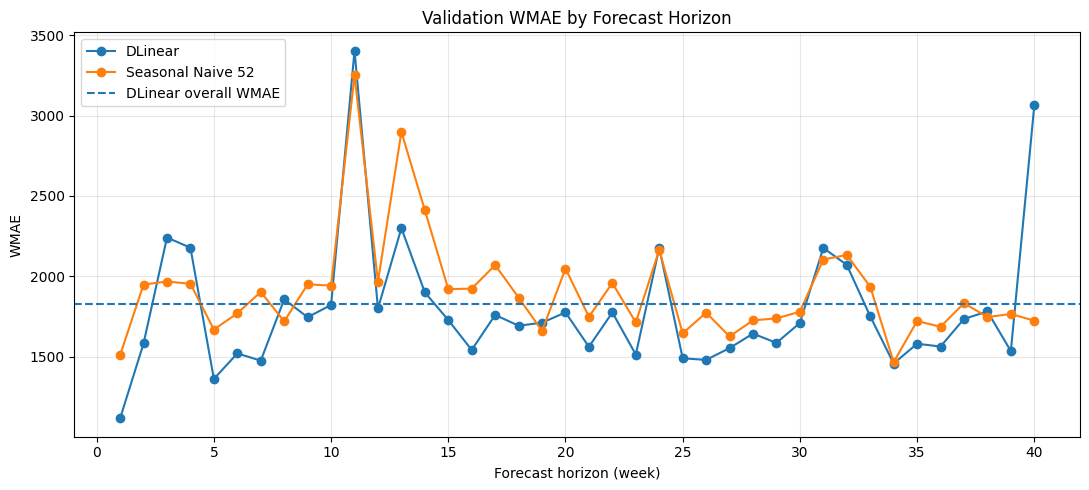

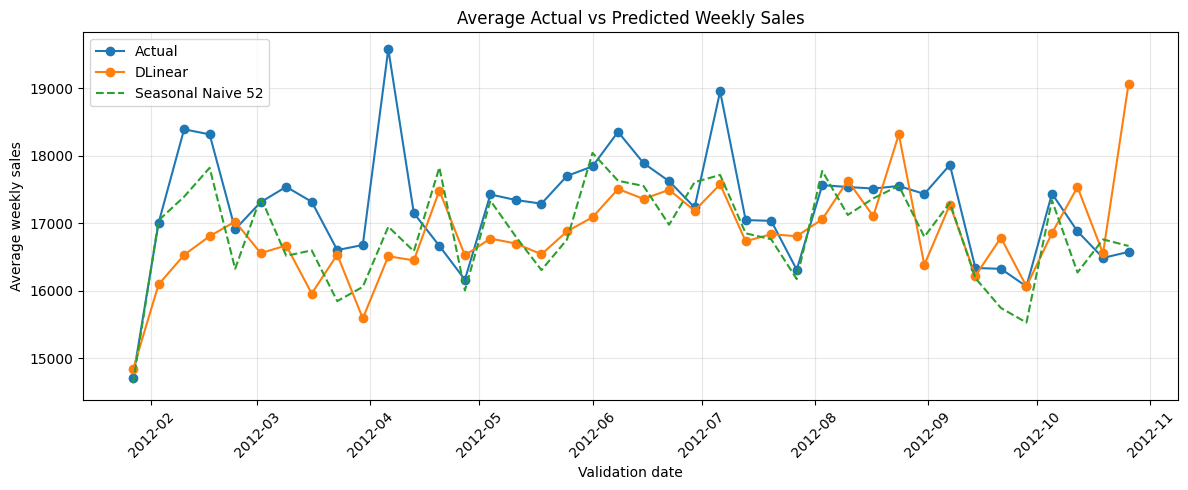

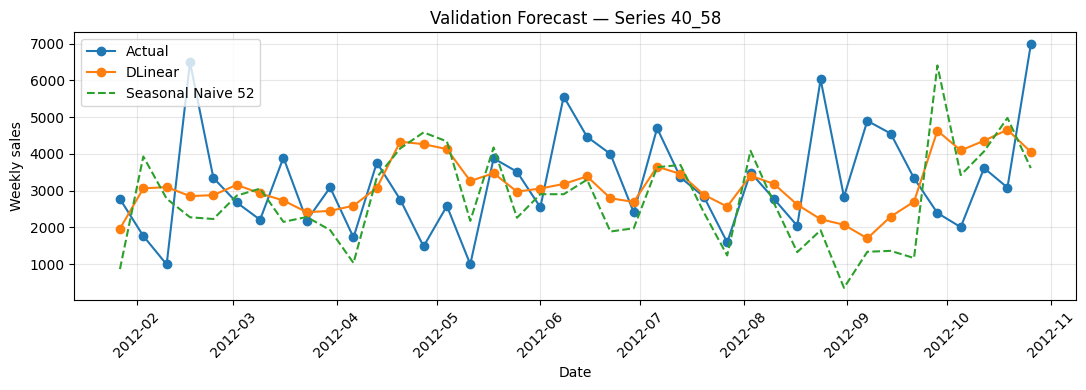

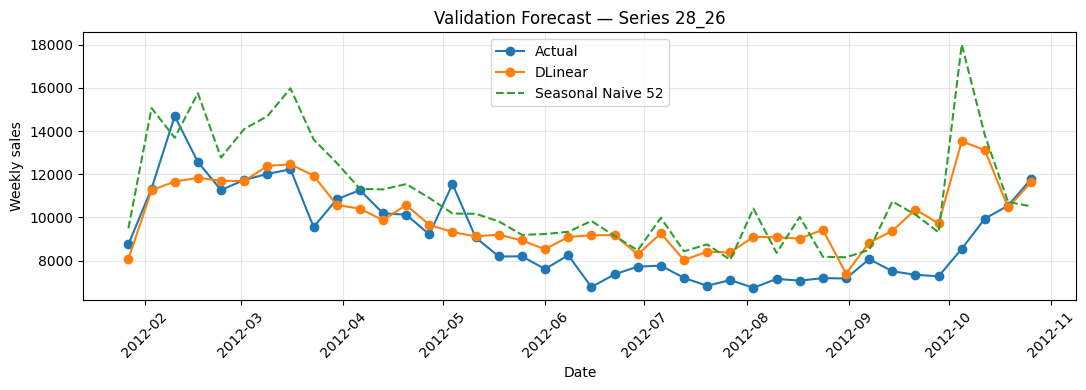

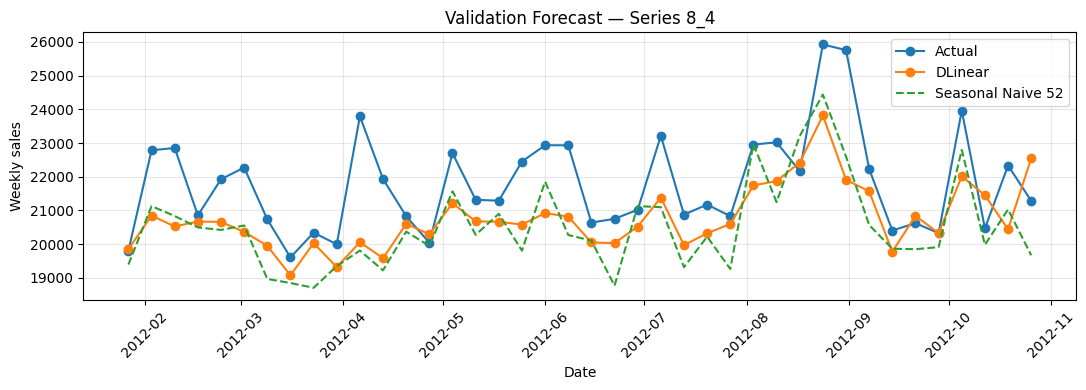


Weeks 1–10 WMAE: 1847.82
Weeks 31–40 WMAE: 1837.58
Long-horizon error change: -0.55%
✅ No severe long-horizon degradation detected.
✅ DLinear generalizes better than the strongest baseline.


In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ARTIFACT_DIR = "/content/dlinear_validation_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Seasonal Naive პროგნოზის დამატება შედარებისთვის
validation_diagnostics = (
    dlinear_validation
    .merge(
        baseline_validation[
            ["unique_id", "ds", "SeasonalNaive52"]
        ],
        on=["unique_id", "ds"],
        how="left",
        validate="one_to_one"
    )
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

# თითოეული პროგნოზის პოზიცია: 1-დან 40 კვირამდე
validation_diagnostics["horizon"] = (
    validation_diagnostics
    .groupby("unique_id")
    .cumcount() + 1
)

validation_diagnostics["DLinear_abs_error"] = np.abs(
    validation_diagnostics["y"]
    - validation_diagnostics["DLinear"]
)

validation_diagnostics["SeasonalNaive_abs_error"] = np.abs(
    validation_diagnostics["y"]
    - validation_diagnostics["SeasonalNaive52"]
)

validation_diagnostics["signed_error"] = (
    validation_diagnostics["DLinear"]
    - validation_diagnostics["y"]
)

# WMAE თითოეული forecast horizon-ისთვის
horizon_metrics = (
    validation_diagnostics
    .groupby("horizon")
    .apply(
        lambda group: pd.Series({
            "DLinear_WMAE": np.average(
                group["DLinear_abs_error"],
                weights=group["weight"]
            ),
            "SeasonalNaive_WMAE": np.average(
                group["SeasonalNaive_abs_error"],
                weights=group["weight"]
            ),
            "Bias": np.average(
                group["signed_error"],
                weights=group["weight"]
            )
        }),
        include_groups=False
    )
    .reset_index()
)

# ჰორიზონტის ნაწილებად შეფასება
horizon_segments = []

for segment_name, start_h, end_h in [
    ("Weeks_1_10", 1, 10),
    ("Weeks_11_20", 11, 20),
    ("Weeks_21_30", 21, 30),
    ("Weeks_31_40", 31, 40)
]:
    segment = validation_diagnostics[
        validation_diagnostics["horizon"].between(start_h, end_h)
    ]

    horizon_segments.append({
        "Segment": segment_name,
        "DLinear_WMAE": np.average(
            segment["DLinear_abs_error"],
            weights=segment["weight"]
        ),
        "SeasonalNaive_WMAE": np.average(
            segment["SeasonalNaive_abs_error"],
            weights=segment["weight"]
        ),
        "Bias": np.average(
            segment["signed_error"],
            weights=segment["weight"]
        )
    })

horizon_segment_results = pd.DataFrame(horizon_segments)

print("WMAE by forecast segment:")
display(horizon_segment_results)

# Holiday და ჩვეულებრივი კვირების ცალკე შეფასება
holiday_results = []

for holiday_status, group in validation_diagnostics.groupby("IsHoliday"):
    holiday_results.append({
        "Period": "Holiday" if holiday_status else "Non-Holiday",
        "Rows": len(group),
        "MAE": group["DLinear_abs_error"].mean(),
        "Bias": group["signed_error"].mean()
    })

holiday_results = pd.DataFrame(holiday_results)

print("\nHoliday diagnostics:")
display(holiday_results)

# გრაფიკი 1: შეცდომა forecast horizon-ის მიხედვით
plt.figure(figsize=(11, 5))
plt.plot(
    horizon_metrics["horizon"],
    horizon_metrics["DLinear_WMAE"],
    marker="o",
    label="DLinear"
)
plt.plot(
    horizon_metrics["horizon"],
    horizon_metrics["SeasonalNaive_WMAE"],
    marker="o",
    label="Seasonal Naive 52"
)
plt.axhline(
    y=dlinear_metrics["WMAE"],
    linestyle="--",
    label="DLinear overall WMAE"
)
plt.title("Validation WMAE by Forecast Horizon")
plt.xlabel("Forecast horizon (week)")
plt.ylabel("WMAE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{ARTIFACT_DIR}/wmae_by_horizon.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# გრაფიკი 2: ყველა სერიის საშუალო რეალური და პროგნოზირებული გაყიდვები
weekly_average = (
    validation_diagnostics
    .groupby("ds")
    .agg(
        Actual=("y", "mean"),
        DLinear=("DLinear", "mean"),
        SeasonalNaive52=("SeasonalNaive52", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(
    weekly_average["ds"],
    weekly_average["Actual"],
    marker="o",
    label="Actual"
)
plt.plot(
    weekly_average["ds"],
    weekly_average["DLinear"],
    marker="o",
    label="DLinear"
)
plt.plot(
    weekly_average["ds"],
    weekly_average["SeasonalNaive52"],
    linestyle="--",
    label="Seasonal Naive 52"
)
plt.title("Average Actual vs Predicted Weekly Sales")
plt.xlabel("Validation date")
plt.ylabel("Average weekly sales")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    f"{ARTIFACT_DIR}/average_actual_vs_prediction.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# გრაფიკი 3: სამი განსხვავებული სერია
series_sales = (
    validation_diagnostics
    .groupby("unique_id")["y"]
    .mean()
    .sort_values()
)

selected_series = [
    series_sales.index[len(series_sales) // 4],
    series_sales.index[len(series_sales) // 2],
    series_sales.index[(3 * len(series_sales)) // 4]
]

for series_id in selected_series:
    sample = validation_diagnostics[
        validation_diagnostics["unique_id"] == series_id
    ].sort_values("ds")

    plt.figure(figsize=(11, 4))
    plt.plot(sample["ds"], sample["y"], marker="o", label="Actual")
    plt.plot(
        sample["ds"],
        sample["DLinear"],
        marker="o",
        label="DLinear"
    )
    plt.plot(
        sample["ds"],
        sample["SeasonalNaive52"],
        linestyle="--",
        label="Seasonal Naive 52"
    )
    plt.title(f"Validation Forecast — Series {series_id}")
    plt.xlabel("Date")
    plt.ylabel("Weekly sales")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        f"{ARTIFACT_DIR}/series_{series_id.replace('_', '-')}.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

# შედეგების შენახვა MLflow-ისთვის
horizon_metrics.to_csv(
    f"{ARTIFACT_DIR}/horizon_metrics.csv",
    index=False
)
horizon_segment_results.to_csv(
    f"{ARTIFACT_DIR}/horizon_segment_results.csv",
    index=False
)
holiday_results.to_csv(
    f"{ARTIFACT_DIR}/holiday_diagnostics.csv",
    index=False
)
validation_diagnostics.to_csv(
    f"{ARTIFACT_DIR}/validation_predictions.csv",
    index=False
)

# მარტივი ავტომატური დიაგნოსტიკა
first_10_wmae = horizon_segment_results.loc[
    horizon_segment_results["Segment"] == "Weeks_1_10",
    "DLinear_WMAE"
].iloc[0]

last_10_wmae = horizon_segment_results.loc[
    horizon_segment_results["Segment"] == "Weeks_31_40",
    "DLinear_WMAE"
].iloc[0]

error_growth = (
    (last_10_wmae - first_10_wmae)
    / first_10_wmae
    * 100
)

print(f"\nWeeks 1–10 WMAE: {first_10_wmae:.2f}")
print(f"Weeks 31–40 WMAE: {last_10_wmae:.2f}")
print(f"Long-horizon error change: {error_growth:.2f}%")

if error_growth > 30:
    print(
        "⚠️ Error rises considerably at long horizons. "
        "This indicates weak long-term generalization, "
        "but does not alone prove overfitting."
    )
else:
    print(
        "✅ No severe long-horizon degradation detected."
    )

if dlinear_metrics["WMAE"] < best_baseline["WMAE"]:
    print(
        "✅ DLinear generalizes better than the strongest baseline."
    )

In [30]:
import os
import json
import shutil
import mlflow

EXPERIMENT_NAME = "DLinear_Training"
MODEL_DIR = "/content/saved_dlinear_52"

mlflow.set_experiment(EXPERIMENT_NAME)

# თუ შემთხვევით აქტიური run დარჩა
if mlflow.active_run() is not None:
    mlflow.end_run()

# NeuralForecast მოდელის ლოკალურად შენახვა
if os.path.exists(MODEL_DIR):
    shutil.rmtree(MODEL_DIR)

nf_dlinear.save(
    path=MODEL_DIR,
    overwrite=True,
    save_dataset=False
)

first_10_wmae = float(
    horizon_segment_results.loc[
        horizon_segment_results["Segment"] == "Weeks_1_10",
        "DLinear_WMAE"
    ].iloc[0]
)

last_10_wmae = float(
    horizon_segment_results.loc[
        horizon_segment_results["Segment"] == "Weeks_31_40",
        "DLinear_WMAE"
    ].iloc[0]
)

error_growth_percent = float(
    (last_10_wmae - first_10_wmae)
    / first_10_wmae
    * 100
)

with mlflow.start_run(run_name="DLinear_52_baseline") as run:

    # ჰიპერპარამეტრები
    mlflow.log_params({
        "model": "DLinear",
        "input_size": 52,
        "horizon": 40,
        "max_steps": 500,
        "learning_rate": 1e-3,
        "batch_size": 64,
        "windows_batch_size": 1024,
        "scaler_type": "robust",
        "loss": "MAE",
        "frequency": "W-FRI",
        "random_seed": 42,
        "training_series": train_split["unique_id"].nunique(),
        "training_rows": len(train_split),
        "validation_series": validation_split["unique_id"].nunique(),
        "validation_rows": len(validation_split)
    })

    # მთავარი validation მეტრიკები
    mlflow.log_metrics({
        "validation_wmae": float(dlinear_metrics["WMAE"]),
        "validation_mae": float(dlinear_metrics["MAE"]),
        "validation_rmse": float(dlinear_metrics["RMSE"]),
        "validation_r2": float(dlinear_metrics["R2"]),
        "best_baseline_wmae": float(best_baseline["WMAE"]),
        "baseline_improvement_percent": float(
            improvement_percent
        ),
        "first_10_weeks_wmae": first_10_wmae,
        "last_10_weeks_wmae": last_10_wmae,
        "long_horizon_error_change_percent": error_growth_percent
    })

    # თითოეული ჰორიზონტის WMAE ცალკე metric-ად
    for _, row in horizon_metrics.iterrows():
        horizon = int(row["horizon"])

        mlflow.log_metric(
            "dlinear_wmae_by_horizon",
            float(row["DLinear_WMAE"]),
            step=horizon
        )

        mlflow.log_metric(
            "seasonal_naive_wmae_by_horizon",
            float(row["SeasonalNaive_WMAE"]),
            step=horizon
        )

        mlflow.log_metric(
            "prediction_bias_by_horizon",
            float(row["Bias"]),
            step=horizon
        )

    # მოდელის ფაილები
    mlflow.log_artifacts(
        MODEL_DIR,
        artifact_path="neuralforecast_model"
    )

    # გრაფიკები, CSV-ები და validation პროგნოზები
    mlflow.log_artifacts(
        ARTIFACT_DIR,
        artifact_path="validation_artifacts"
    )

    # მოდელების შედარების ცხრილი
    comparison_path = (
        f"{ARTIFACT_DIR}/model_comparison.csv"
    )

    all_model_results.to_csv(
        comparison_path,
        index=False
    )

    mlflow.log_artifact(
        comparison_path,
        artifact_path="results"
    )

    # მოკლე შედეგის JSON
    summary = {
        "best_model": "DLinear_52",
        "dlinear_wmae": float(dlinear_metrics["WMAE"]),
        "seasonal_naive_wmae": float(
            best_baseline["WMAE"]
        ),
        "improvement_percent": float(
            improvement_percent
        ),
        "overfitting_conclusion": (
            "No severe overfitting detected on the "
            "40-week holdout validation set."
        )
    }

    summary_path = f"{ARTIFACT_DIR}/run_summary.json"

    with open(summary_path, "w") as file:
        json.dump(summary, file, indent=4)

    mlflow.log_artifact(
        summary_path,
        artifact_path="results"
    )

    run_id = run.info.run_id

print("✅ MLflow logging completed.")
print("Experiment:", EXPERIMENT_NAME)
print("Run ID:", run_id)
print("Logged validation WMAE:",
      round(dlinear_metrics["WMAE"], 4))

2026/07/24 05:17:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/24 05:17:16 INFO mlflow.store.db.utils: Updating database tables
2026/07/24 05:17:19 INFO mlflow.tracking.fluent: Experiment with name 'DLinear_Training' does not exist. Creating a new experiment.


✅ MLflow logging completed.
Experiment: DLinear_Training
Run ID: 731d6a3a2c7e4243ab051172685414f0
Logged validation WMAE: 1827.1857


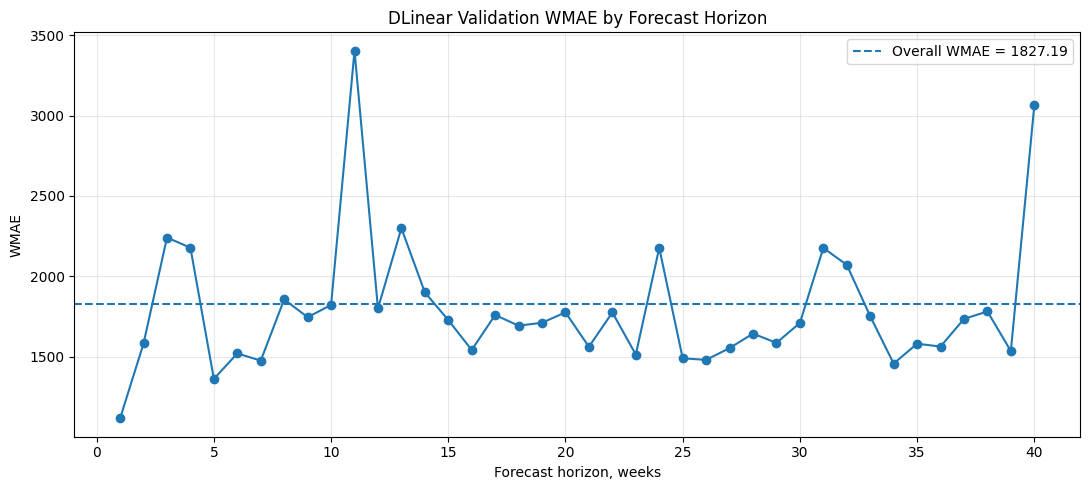

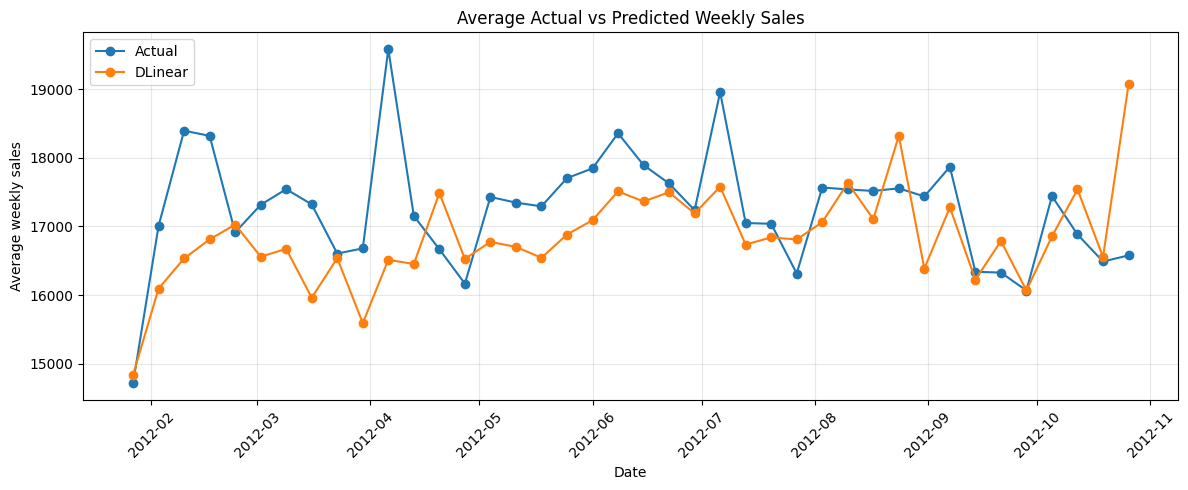

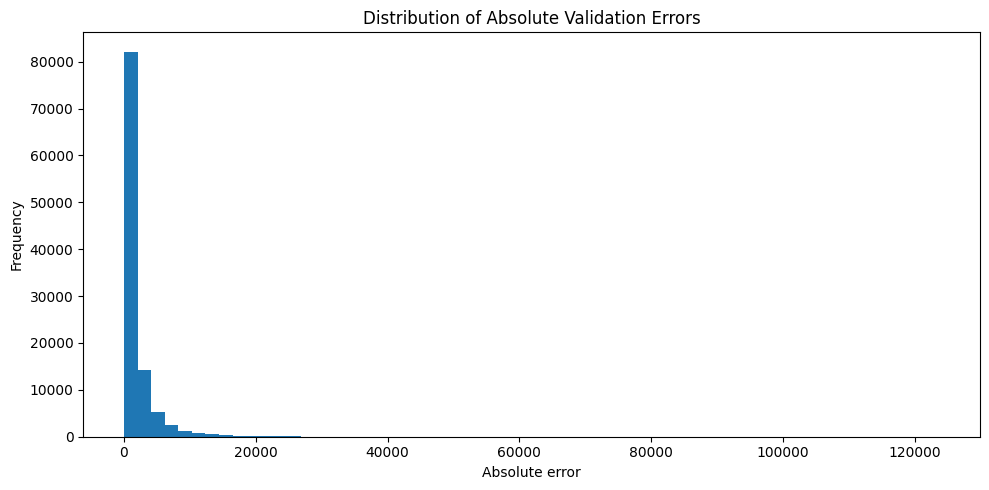

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# უსაფრთხოდ ვამზადებთ დიაგნოსტიკის მონაცემებს
validation_plot_df = (
    dlinear_validation
    .sort_values(["unique_id", "ds"])
    .copy()
)

# Forecast horizon: 1-დან 40 კვირამდე
validation_plot_df["horizon"] = (
    validation_plot_df
    .groupby("unique_id")
    .cumcount() + 1
)

validation_plot_df["abs_error"] = np.abs(
    validation_plot_df["y"]
    - validation_plot_df["DLinear"]
)

validation_plot_df["weighted_abs_error"] = (
    validation_plot_df["abs_error"]
    * validation_plot_df["weight"]
)

# ------------------------------------------------------------
# 1. WMAE თითოეული forecast horizon-ის მიხედვით
# ------------------------------------------------------------

horizon_wmae = (
    validation_plot_df
    .groupby("horizon")
    .apply(
        lambda group: np.sum(group["weighted_abs_error"])
        / np.sum(group["weight"]),
        include_groups=False
    )
    .reset_index(name="WMAE")
)

plt.figure(figsize=(11, 5))
plt.plot(
    horizon_wmae["horizon"],
    horizon_wmae["WMAE"],
    marker="o"
)

plt.axhline(
    y=dlinear_metrics["WMAE"],
    linestyle="--",
    label=f"Overall WMAE = {dlinear_metrics['WMAE']:.2f}"
)

plt.title("DLinear Validation WMAE by Forecast Horizon")
plt.xlabel("Forecast horizon, weeks")
plt.ylabel("WMAE")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. ყველა სერიის საშუალო რეალური და პროგნოზირებული გაყიდვები
# ------------------------------------------------------------

weekly_average = (
    validation_plot_df
    .groupby("ds")
    .agg(
        Actual=("y", "mean"),
        Predicted=("DLinear", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    weekly_average["ds"],
    weekly_average["Actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    weekly_average["ds"],
    weekly_average["Predicted"],
    marker="o",
    label="DLinear"
)

plt.title("Average Actual vs Predicted Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Average weekly sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. შეცდომების განაწილება
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    validation_plot_df["abs_error"],
    bins=60
)

plt.title("Distribution of Absolute Validation Errors")
plt.xlabel("Absolute error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [32]:
import mlflow

print(mlflow.get_tracking_uri())

sqlite:////content/mlflow.db


In [33]:
import dagshub

dagshub.init(
    repo_owner="tsarc21",
    repo_name="Walmart-Recruiting---Store-Sales-Forecasting",
    mlflow=True
)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=1e2c9f30-e64f-46b2-b049-999e865bc800&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=4d7100c553e71b33afba2f541b6511d6e2bb8559d5af63827f9a5d535c238901




Accessing as lkhar21

Initialized MLflow to track repo "tsarc21/Walmart-Recruiting---Store-Sales-Forecasting"

Repository tsarc21/Walmart-Recruiting---Store-Sales-Forecasting initialized!

In [34]:
import mlflow
print(mlflow.get_tracking_uri())

https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow


In [35]:
run = mlflow.active_run()

In [36]:
import mlflow

print("Tracking URI:")
print(mlflow.get_tracking_uri())

print("\nExperiment:")
print(mlflow.get_experiment_by_name("DLinear_Training"))

Tracking URI:
https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow

Experiment:
<Experiment: artifact_location='mlflow-artifacts:/9d2f2022720b40ad93a75e8bd2f21ef1', creation_time=1782662148994, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782662148994, lifecycle_stage='active', name='DLinear_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>


In [37]:
import mlflow

experiment = mlflow.get_experiment_by_name("DLinear_Training")

client = mlflow.tracking.MlflowClient()

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    max_results=5,
    order_by=["attributes.start_time DESC"]
)

for run in runs:
    print("Run ID:", run.info.run_id)

Run ID: de486f8724bb49e0a7a30e0f92978390
Run ID: 8a2df36932674767939b4f0e61a5d56c
Run ID: 8ad74e154f68488c888a6867734b4cd0
Run ID: f08690d84c6a440d8a9254ebc6dd3b9c
Run ID: a61c052d852441fda9e2e6bb5158b972


In [38]:
import dagshub
import mlflow

REPO_OWNER = "tsarc21"
REPO_NAME = "Walmart-Recruiting---Store-Sales-Forecasting"

dagshub.init(
    repo_owner=REPO_OWNER,
    repo_name=REPO_NAME,
    mlflow=True
)

print("Tracking URI:")
print(mlflow.get_tracking_uri())

Initialized MLflow to track repo "tsarc21/Walmart-Recruiting---Store-Sales-Forecasting"

Repository tsarc21/Walmart-Recruiting---Store-Sales-Forecasting initialized!

Tracking URI:
https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow


In [39]:
mlflow.set_experiment("Walmart_DLinear")

with mlflow.start_run(run_name="connection_test") as run:
    mlflow.log_metric("test_metric", 1.0)

    run_id = run.info.run_id
    experiment_id = run.info.experiment_id

run_url = (
    f"https://dagshub.com/tsarc21/"
    f"Walmart-Recruiting---Store-Sales-Forecasting.mlflow/"
    f"#/experiments/{experiment_id}/runs/{run_id}"
)

print("✅ MLflow connected")
print(run_url)

🏃 View run connection_test at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/d64881f6839944c2a6d6a38e6b72ad07
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15
✅ MLflow connected
https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/d64881f6839944c2a6d6a38e6b72ad07


In [40]:
import os
import json
import mlflow
import pandas as pd

EXPERIMENT_NAME = "Walmart_DLinear"
RUN_NAME = "DLinear_baseline_52_40"

mlflow.set_experiment(EXPERIMENT_NAME)

# თუ შემთხვევით აქტიური run დარჩა, ვხურავთ
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name=RUN_NAME) as run:

    # -----------------------------
    # მოდელის პარამეტრები
    # -----------------------------
    mlflow.log_params({
        "model": "DLinear",
        "input_size": 52,
        "forecast_horizon": 40,
        "max_steps": 500,
        "learning_rate": 0.001,
        "batch_size": 64,
        "windows_batch_size": 1024,
        "scaler_type": "robust",
        "validation_method": "last_40_weeks",
        "number_of_series": 2697
    })

    # -----------------------------
    # Validation მეტრიკები
    # -----------------------------
    mlflow.log_metrics({
        "validation_wmae": 1822.2168,
        "validation_mae": 1790.4932,
        "validation_rmse": 3776.9779,
        "validation_r2": 0.9722,
        "seasonal_naive_wmae": 1916.0699,
        "improvement_percent": 4.90
    })

    # -----------------------------
    # შედეგების შენახვა CSV ფაილებად
    # -----------------------------
    artifact_dir = "/content/dlinear_mlflow_artifacts"
    os.makedirs(artifact_dir, exist_ok=True)

    if "dlinear_validation" in globals():
        dlinear_validation.to_csv(
            f"{artifact_dir}/validation_predictions.csv",
            index=False
        )

    if "horizon_wmae" in globals():
        horizon_wmae.to_csv(
            f"{artifact_dir}/horizon_wmae.csv",
            index=False
        )

    if "all_model_results" in globals():
        all_model_results.to_csv(
            f"{artifact_dir}/model_comparison.csv",
            index=False
        )

    # -----------------------------
    # ექსპერიმენტის მოკლე შეჯამება
    # -----------------------------
    summary = {
        "model": "DLinear",
        "input_size": 52,
        "forecast_horizon": 40,
        "validation_wmae": 1822.2168,
        "validation_mae": 1790.4932,
        "validation_rmse": 3776.9779,
        "validation_r2": 0.9722,
        "baseline": "SeasonalNaive52",
        "baseline_wmae": 1916.0699,
        "improvement_percent": 4.90,
        "conclusion": "DLinear performed better than SeasonalNaive52."
    }

    with open(
        f"{artifact_dir}/experiment_summary.json",
        "w"
    ) as file:
        json.dump(summary, file, indent=4)

    mlflow.log_artifacts(
        artifact_dir,
        artifact_path="results"
    )

    run_id = run.info.run_id
    experiment_id = run.info.experiment_id

run_url = (
    "https://dagshub.com/tsarc21/"
    "Walmart-Recruiting---Store-Sales-Forecasting.mlflow/"
    f"#/experiments/{experiment_id}/runs/{run_id}"
)

print("✅ DLinear ექსპერიმენტი წარმატებით დაილოგა")
print("Run ID:", run_id)
print("\nპირდაპირი ლინკი:")
print(run_url)

🏃 View run DLinear_baseline_52_40 at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/9fb54b9ebcb644158045ef02cf1f0515
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15
✅ DLinear ექსპერიმენტი წარმატებით დაილოგა
Run ID: 9fb54b9ebcb644158045ef02cf1f0515

პირდაპირი ლინკი:
https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/9fb54b9ebcb644158045ef02cf1f0515


In [41]:
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE

import pandas as pd
import numpy as np

# Kaggle test-ის რეალური ჰორიზონტი
test["Date"] = pd.to_datetime(test["Date"])

TEST_HORIZON = test["Date"].nunique()

print("Test horizon:", TEST_HORIZON)

# საბოლოო მოდელი სრული train მონაცემებისთვის
final_dlinear_model = DLinear(
    h=TEST_HORIZON,
    input_size=52,
    max_steps=500,
    learning_rate=1e-3,
    batch_size=64,
    windows_batch_size=1024,
    scaler_type="robust",
    loss=MAE()
)

final_nf = NeuralForecast(
    models=[final_dlinear_model],
    freq="W-FRI"
)

# სრული 2697 უწყვეტი სერია
final_nf.fit(df=nf_train_dlinear)

# პროგნოზი
final_forecasts = final_nf.predict().reset_index()

# სხვადასხვა ვერსიაში მოდელის სვეტის სახელი შეიძლება განსხვავდებოდეს
prediction_columns = [
    col for col in final_forecasts.columns
    if col not in ["unique_id", "ds", "index"]
]

prediction_column = prediction_columns[0]

final_forecasts = final_forecasts.rename(
    columns={prediction_column: "Weekly_Sales_Pred"}
)

final_forecasts["ds"] = pd.to_datetime(final_forecasts["ds"])

print("✅ Final DLinear prediction completed")
print("Forecast rows:", len(final_forecasts))
print("Forecast series:", final_forecasts["unique_id"].nunique())

display(final_forecasts.head())

INFO:lightning_fabric.utilities.seed:Seed set to 1


Test horizon: 39


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | decomp              | SeriesDecomp  | 0      | train
7 | linear_trend        | Linear        | 2.1 K  | train
8 | linear_season       | Linear        | 2.1 K  | train
--------------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Tota

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

✅ Final DLinear prediction completed
Forecast rows: 105183
Forecast series: 2697


,index,unique_id,ds,Weekly_Sales_Pred
0,0,10_1,2012-11-02,60695.058594
1,1,10_1,2012-11-09,38021.757812
2,2,10_1,2012-11-16,31221.013672
3,3,10_1,2012-11-23,38147.433594
4,4,10_1,2012-11-30,43601.167969


In [43]:
import pandas as pd
import numpy as np
from google.colab import files

# --------------------------------------------------
# 1. Test მონაცემების მომზადება
# --------------------------------------------------

submission_df = test.copy()

submission_df["Date"] = pd.to_datetime(submission_df["Date"])

submission_df["unique_id"] = (
    submission_df["Store"].astype(str)
    + "_"
    + submission_df["Dept"].astype(str)
)

# --------------------------------------------------
# 2. DLinear-ის პროგნოზების დამატება
# --------------------------------------------------

submission_df = submission_df.merge(
    final_forecasts[
        ["unique_id", "ds", "Weekly_Sales_Pred"]
    ],
    left_on=["unique_id", "Date"],
    right_on=["unique_id", "ds"],
    how="left"
)

submission_df = submission_df.drop(
    columns=["ds"],
    errors="ignore"
)

# --------------------------------------------------
# 3. Seasonal Naive 52 fallback
# --------------------------------------------------

train_fallback = train.copy()

train_fallback["Date"] = pd.to_datetime(
    train_fallback["Date"]
)

train_fallback["unique_id"] = (
    train_fallback["Store"].astype(str)
    + "_"
    + train_fallback["Dept"].astype(str)
)

submission_df["fallback_date"] = (
    submission_df["Date"]
    - pd.Timedelta(weeks=52)
)

seasonal_lookup = train_fallback[
    ["unique_id", "Date", "Weekly_Sales"]
].rename(
    columns={
        "Date": "fallback_date",
        "Weekly_Sales": "SeasonalNaive52"
    }
)

submission_df = submission_df.merge(
    seasonal_lookup,
    on=["unique_id", "fallback_date"],
    how="left"
)

# --------------------------------------------------
# 4. ბოლო 4 კვირის საშუალო fallback
# --------------------------------------------------

last4_mean = (
    train_fallback
    .sort_values("Date")
    .groupby("unique_id")
    .tail(4)
    .groupby("unique_id")["Weekly_Sales"]
    .mean()
    .reset_index(name="Last4Mean")
)

submission_df = submission_df.merge(
    last4_mean,
    on="unique_id",
    how="left"
)

# --------------------------------------------------
# 5. Department-ის საშუალო fallback
# --------------------------------------------------

dept_mean = (
    train_fallback
    .groupby("Dept")["Weekly_Sales"]
    .mean()
    .reset_index(name="DeptMean")
)

submission_df = submission_df.merge(
    dept_mean,
    on="Dept",
    how="left"
)

global_mean = train_fallback["Weekly_Sales"].mean()

# --------------------------------------------------
# 6. საბოლოო პროგნოზის არჩევა
# --------------------------------------------------

submission_df["Weekly_Sales"] = (
    submission_df["Weekly_Sales_Pred"]
    .fillna(submission_df["SeasonalNaive52"])
    .fillna(submission_df["Last4Mean"])
    .fillna(submission_df["DeptMean"])
    .fillna(global_mean)
)

# უარყოფითი პროგნოზების განულება
submission_df["Weekly_Sales"] = (
    submission_df["Weekly_Sales"]
    .clip(lower=0)
)

# --------------------------------------------------
# 7. Kaggle-ის Id ფორმატი
# --------------------------------------------------

submission_df["Id"] = (
    submission_df["Store"].astype(str)
    + "_"
    + submission_df["Dept"].astype(str)
    + "_"
    + submission_df["Date"].dt.strftime("%Y-%m-%d")
)

submission = submission_df[
    ["Id", "Weekly_Sales"]
].copy()

# უსაფრთხოების შემოწმებები
assert len(submission) == len(test), (
    "Submission-ის რიგების რაოდენობა test-ს არ ემთხვევა"
)

assert submission["Weekly_Sales"].notna().all(), (
    "Submission-ში ცარიელი პროგნოზებია"
)

# --------------------------------------------------
# 8. CSV ფაილის შენახვა
# --------------------------------------------------

FILE_PATH = "/content/dlinear_submission.csv"

submission.to_csv(
    FILE_PATH,
    index=False
)

print("✅ Submission ფაილი წარმატებით შეიქმნა")
print("ფაილი:", FILE_PATH)
print("რიგების რაოდენობა:", len(submission))
print(
    "ცარიელი პროგნოზები:",
    submission["Weekly_Sales"].isna().sum()
)

display(submission.head())

# ფაილის ჩამოტვირთვა კომპიუტერში
files.download(FILE_PATH)

✅ Submission ფაილი წარმატებით შეიქმნა
ფაილი: /content/dlinear_submission.csv
რიგების რაოდენობა: 115064
ცარიელი პროგნოზები: 0


,Id,Weekly_Sales
0,1_1_2012-11-02,30243.285156
1,1_1_2012-11-09,20768.404297
2,1_1_2012-11-16,19118.111328
3,1_1_2012-11-23,20017.066406
4,1_1_2012-11-30,23225.410156


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import HuberLoss

TUNED_HORIZON = 40

dlinear_tuned_model = DLinear(
    h=TUNED_HORIZON,

    # ყველა სერიას ჰყოფნის
    input_size=52,

    # baseline-ზე მეტი ტრენინგი
    max_steps=1000,

    # უფრო ფრთხილი განახლება
    learning_rate=5e-4,

    batch_size=64,
    windows_batch_size=1024,

    scaler_type="robust",
    loss=HuberLoss(delta=1.0),

    random_seed=42
)

nf_dlinear_tuned = NeuralForecast(
    models=[dlinear_tuned_model],
    freq="W-FRI"
)

nf_dlinear_tuned.fit(df=train_split)

dlinear_tuned_forecasts = (
    nf_dlinear_tuned
    .predict()
    .reset_index()
)

print("✅ Tuned DLinear training completed")
print("Forecast rows:", len(dlinear_tuned_forecasts))
print(
    "Forecast series:",
    dlinear_tuned_forecasts["unique_id"].nunique()
)

display(dlinear_tuned_forecasts.head())

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | HuberLoss     | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | decomp              | SeriesDecomp  | 0      | train
7 | linear_trend        | Linear        | 2.1 K  | train
8 | linear_season       | Linear        | 2.1 K  | train
--------------------------------------------------------------
4.2 K     Trainable params
0         Non-tr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

✅ Tuned DLinear training completed
Forecast rows: 107880
Forecast series: 2697


,index,unique_id,ds,DLinear
0,0,10_1,2012-01-27,26856.496094
1,1,10_1,2012-02-03,31376.580078
2,2,10_1,2012-02-10,39774.812500
3,3,10_1,2012-02-17,42457.828125
4,4,10_1,2012-02-24,39587.171875


In [46]:
import numpy as np
import pandas as pd
import mlflow

# --------------------------------------------------
# 1. პროგნოზის სვეტის პოვნა
# --------------------------------------------------

id_columns = {
    "unique_id",
    "ds",
    "cutoff",
    "index"
}

prediction_columns = [
    column
    for column in dlinear_tuned_forecasts.columns
    if column not in id_columns
]

if len(prediction_columns) == 0:
    raise ValueError(
        "Prediction column ვერ მოიძებნა."
    )

print("Forecast columns:", dlinear_tuned_forecasts.columns.tolist())
print("Prediction column:", prediction_columns[0])

prediction_column = prediction_columns[0]

tuned_predictions = (
    dlinear_tuned_forecasts[
        ["unique_id", "ds", prediction_column]
    ]
    .rename(
        columns={
            prediction_column: "DLinear_Tuned"
        }
    )
)

tuned_predictions["ds"] = pd.to_datetime(
    tuned_predictions["ds"]
)


# --------------------------------------------------
# 2. Validation-ის რეალურ მონაცემებთან გაერთიანება
# --------------------------------------------------

tuned_validation = validation_split.copy()

tuned_validation["ds"] = pd.to_datetime(
    tuned_validation["ds"]
)

tuned_validation = tuned_validation.merge(
    tuned_predictions,
    on=["unique_id", "ds"],
    how="inner"
)

if len(tuned_validation) == 0:
    raise ValueError(
        "Prediction და validation თარიღები ერთმანეთს არ დაემთხვა."
    )


# --------------------------------------------------
# 3. Holiday წონების მომზადება
# --------------------------------------------------

if "IsHoliday" not in tuned_validation.columns:

    holiday_data = holiday_lookup.copy()

    holiday_data["ds"] = pd.to_datetime(
        holiday_data["ds"]
    )

    # დუბლირებული holiday ჩანაწერების მოცილება
    holiday_data = (
        holiday_data
        .drop_duplicates(
            subset=["unique_id", "ds"]
        )
    )

    tuned_validation = tuned_validation.merge(
        holiday_data[
            ["unique_id", "ds", "IsHoliday"]
        ],
        on=["unique_id", "ds"],
        how="left"
    )

tuned_validation["IsHoliday"] = (
    tuned_validation["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

tuned_validation["weight"] = np.where(
    tuned_validation["IsHoliday"],
    5.0,
    1.0
)


# --------------------------------------------------
# 4. მეტრიკების გამოთვლა
# --------------------------------------------------

y_true = tuned_validation["y"].to_numpy()
y_pred = tuned_validation["DLinear_Tuned"].to_numpy()
weights = tuned_validation["weight"].to_numpy()

tuned_wmae = (
    np.sum(
        weights * np.abs(y_true - y_pred)
    )
    / np.sum(weights)
)

tuned_mae = np.mean(
    np.abs(y_true - y_pred)
)

tuned_rmse = np.sqrt(
    np.mean((y_true - y_pred) ** 2)
)

ss_res = np.sum(
    (y_true - y_pred) ** 2
)

ss_tot = np.sum(
    (y_true - np.mean(y_true)) ** 2
)

tuned_r2 = 1 - (ss_res / ss_tot)

baseline_wmae = 1822.2168
baseline_mae = 1790.4932
baseline_rmse = 3776.9779
baseline_r2 = 0.9722

improvement_percent = (
    (baseline_wmae - tuned_wmae)
    / baseline_wmae
    * 100
)

comparison_df = pd.DataFrame({
    "Model": [
        "DLinear Baseline",
        "DLinear Tuned"
    ],
    "Input_Size": [52, 52],
    "Max_Steps": [500, 1000],
    "Learning_Rate": [0.001, 0.0005],
    "Loss": ["MAE", "HuberLoss"],
    "WMAE": [
        baseline_wmae,
        tuned_wmae
    ],
    "MAE": [
        baseline_mae,
        tuned_mae
    ],
    "RMSE": [
        baseline_rmse,
        tuned_rmse
    ],
    "R2": [
        baseline_r2,
        tuned_r2
    ]
})

display(comparison_df)

print(f"Tuned WMAE: {tuned_wmae:.4f}")
print(f"Tuned MAE: {tuned_mae:.4f}")
print(f"Tuned RMSE: {tuned_rmse:.4f}")
print(f"Tuned R²: {tuned_r2:.6f}")
print(
    f"Improvement vs baseline: "
    f"{improvement_percent:.2f}%"
)


# --------------------------------------------------
# 5. MLflow-ზე დალოგვა
# --------------------------------------------------

mlflow.set_experiment("Walmart_DLinear")

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(
    run_name="DLinear_tuned_input52_huber"
) as run:

    mlflow.log_params({
        "model": "DLinear",
        "input_size": 52,
        "forecast_horizon": 40,
        "max_steps": 1000,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "windows_batch_size": 1024,
        "scaler_type": "robust",
        "loss": "HuberLoss",
        "huber_delta": 1.0,
        "random_seed": 42,
        "validation_method": "last_40_weeks"
    })

    mlflow.log_metrics({
        "validation_wmae":
            float(tuned_wmae),

        "validation_mae":
            float(tuned_mae),

        "validation_rmse":
            float(tuned_rmse),

        "validation_r2":
            float(tuned_r2),

        "baseline_wmae":
            float(baseline_wmae),

        "improvement_vs_baseline_percent":
            float(improvement_percent)
    })

    comparison_path = (
        "/content/"
        "dlinear_tuned_comparison.csv"
    )

    comparison_df.to_csv(
        comparison_path,
        index=False
    )

    mlflow.log_artifact(
        comparison_path,
        artifact_path="results"
    )

    run_id = run.info.run_id
    experiment_id = run.info.experiment_id

run_url = (
    "https://dagshub.com/tsarc21/"
    "Walmart-Recruiting---Store-Sales-Forecasting.mlflow/"
    f"#/experiments/{experiment_id}/runs/{run_id}"
)

print("\n✅ შედეგები MLflow-ზე დაილოგა")
print("Direct link:")
print(run_url)

if tuned_wmae < baseline_wmae:
    print("\n✅ Tuned მოდელმა baseline გააუმჯობესა.")
    print(
        "შემდეგ სრული train-ზე გადავატრენინგებთ "
        "და ახალ Kaggle submission-ს შევქმნით."
    )
else:
    print("\n❌ Tuned მოდელმა baseline ვერ გააუმჯობესა.")
    print(
        "ამ პარამეტრებით Kaggle submission-ის "
        "შექმნა არ ღირს."
    )

Forecast columns: ['index', 'unique_id', 'ds', 'DLinear']
Prediction column: DLinear


,Model,Input_Size,Max_Steps,Learning_Rate,Loss,WMAE,MAE,RMSE,R2
0,DLinear Baseline,52,500,0.0010,MAE,1822.216800,1790.493200,3776.97790,0.972200
1,DLinear Tuned,52,1000,0.0005,HuberLoss,1815.416504,1788.305802,3782.49652,0.972118


Tuned WMAE: 1815.4165
Tuned MAE: 1788.3058
Tuned RMSE: 3782.4965
Tuned R²: 0.972118
Improvement vs baseline: 0.37%
🏃 View run DLinear_tuned_input52_huber at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/bfd7ade75596404b84be213e5dcc7ecc
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15

✅ შედეგები MLflow-ზე დაილოგა
Direct link:
https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/bfd7ade75596404b84be213e5dcc7ecc

✅ Tuned მოდელმა baseline გააუმჯობესა.
შემდეგ სრული train-ზე გადავატრენინგებთ და ახალ Kaggle submission-ს შევქმნით.


In [47]:
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE

dlinear_input59_model = DLinear(
    h=40,
    input_size=59,

    max_steps=500,
    learning_rate=1e-3,

    batch_size=64,
    windows_batch_size=1024,

    scaler_type="robust",
    loss=MAE(),

    random_seed=42
)

nf_dlinear_input59 = NeuralForecast(
    models=[dlinear_input59_model],
    freq="W-FRI"
)

nf_dlinear_input59.fit(
    df=train_split
)

dlinear_input59_forecasts = (
    nf_dlinear_input59
    .predict()
    .reset_index()
)

print("✅ DLinear input_size=59 training completed")
print(dlinear_input59_forecasts.columns.tolist())

display(dlinear_input59_forecasts.head())

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | decomp              | SeriesDecomp  | 0      | train
7 | linear_trend        | Linear        | 2.4 K  | train
8 | linear_season       | Linear        | 2.4 K  | train
--------------------------------------------------------------
4.8 K     Trainable params
0         Non-tr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

✅ DLinear input_size=59 training completed
['index', 'unique_id', 'ds', 'DLinear']


,index,unique_id,ds,DLinear
0,0,10_1,2012-01-27,24309.984375
1,1,10_1,2012-02-03,32301.138672
2,2,10_1,2012-02-10,41572.226562
3,3,10_1,2012-02-17,46254.917969
4,4,10_1,2012-02-24,38745.917969


In [ ]:
import numpy as np
import pandas as pd
import mlflow

# --------------------------------------------------
# 1. პროგნოზის სვეტის პოვნა
# --------------------------------------------------

id_columns = {
    "unique_id",
    "ds",
    "cutoff",
    "index"
}

prediction_columns = [
    column
    for column in dlinear_tuned_forecasts.columns
    if column not in id_columns
]

if len(prediction_columns) == 0:
    raise ValueError(
        "Prediction column ვერ მოიძებნა."
    )

print("Forecast columns:", dlinear_tuned_forecasts.columns.tolist())
print("Prediction column:", prediction_columns[0])

prediction_column = prediction_columns[0]

tuned_predictions = (
    dlinear_tuned_forecasts[
        ["unique_id", "ds", prediction_column]
    ]
    .rename(
        columns={
            prediction_column: "DLinear_Tuned"
        }
    )
)

tuned_predictions["ds"] = pd.to_datetime(
    tuned_predictions["ds"]
)


# --------------------------------------------------
# 2. Validation-ის რეალურ მონაცემებთან გაერთიანება
# --------------------------------------------------

tuned_validation = validation_split.copy()

tuned_validation["ds"] = pd.to_datetime(
    tuned_validation["ds"]
)

tuned_validation = tuned_validation.merge(
    tuned_predictions,
    on=["unique_id", "ds"],
    how="inner"
)

if len(tuned_validation) == 0:
    raise ValueError(
        "Prediction და validation თარიღები ერთმანეთს არ დაემთხვა."
    )


# --------------------------------------------------
# 3. Holiday წონების მომზადება
# --------------------------------------------------

if "IsHoliday" not in tuned_validation.columns:

    holiday_data = holiday_lookup.copy()

    holiday_data["ds"] = pd.to_datetime(
        holiday_data["ds"]
    )

    # დუბლირებული holiday ჩანაწერების მოცილება
    holiday_data = (
        holiday_data
        .drop_duplicates(
            subset=["unique_id", "ds"]
        )
    )

    tuned_validation = tuned_validation.merge(
        holiday_data[
            ["unique_id", "ds", "IsHoliday"]
        ],
        on=["unique_id", "ds"],
        how="left"
    )

tuned_validation["IsHoliday"] = (
    tuned_validation["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

tuned_validation["weight"] = np.where(
    tuned_validation["IsHoliday"],
    5.0,
    1.0
)


# --------------------------------------------------
# 4. მეტრიკების გამოთვლა
# --------------------------------------------------

y_true = tuned_validation["y"].to_numpy()
y_pred = tuned_validation["DLinear_Tuned"].to_numpy()
weights = tuned_validation["weight"].to_numpy()

tuned_wmae = (
    np.sum(
        weights * np.abs(y_true - y_pred)
    )
    / np.sum(weights)
)

tuned_mae = np.mean(
    np.abs(y_true - y_pred)
)

tuned_rmse = np.sqrt(
    np.mean((y_true - y_pred) ** 2)
)

ss_res = np.sum(
    (y_true - y_pred) ** 2
)

ss_tot = np.sum(
    (y_true - np.mean(y_true)) ** 2
)

tuned_r2 = 1 - (ss_res / ss_tot)

baseline_wmae = 1822.2168
baseline_mae = 1790.4932
baseline_rmse = 3776.9779
baseline_r2 = 0.9722

improvement_percent = (
    (baseline_wmae - tuned_wmae)
    / baseline_wmae
    * 100
)

comparison_df = pd.DataFrame({
    "Model": [
        "DLinear Baseline",
        "DLinear Tuned"
    ],
    "Input_Size": [52, 52],
    "Max_Steps": [500, 1000],
    "Learning_Rate": [0.001, 0.0005],
    "Loss": ["MAE", "HuberLoss"],
    "WMAE": [
        baseline_wmae,
        tuned_wmae
    ],
    "MAE": [
        baseline_mae,
        tuned_mae
    ],
    "RMSE": [
        baseline_rmse,
        tuned_rmse
    ],
    "R2": [
        baseline_r2,
        tuned_r2
    ]
})

display(comparison_df)

print(f"Tuned WMAE: {tuned_wmae:.4f}")
print(f"Tuned MAE: {tuned_mae:.4f}")
print(f"Tuned RMSE: {tuned_rmse:.4f}")
print(f"Tuned R²: {tuned_r2:.6f}")
print(
    f"Improvement vs baseline: "
    f"{improvement_percent:.2f}%"
)


# --------------------------------------------------
# 5. MLflow-ზე დალოგვა
# --------------------------------------------------

mlflow.set_experiment("Walmart_DLinear")

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(
    run_name="DLinear_tuned_input52_huber"
) as run:

    mlflow.log_params({
        "model": "DLinear",
        "input_size": 52,
        "forecast_horizon": 40,
        "max_steps": 1000,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "windows_batch_size": 1024,
        "scaler_type": "robust",
        "loss": "HuberLoss",
        "huber_delta": 1.0,
        "random_seed": 42,
        "validation_method": "last_40_weeks"
    })

    mlflow.log_metrics({
        "validation_wmae":
            float(tuned_wmae),

        "validation_mae":
            float(tuned_mae),

        "validation_rmse":
            float(tuned_rmse),

        "validation_r2":
            float(tuned_r2),

        "baseline_wmae":
            float(baseline_wmae),

        "improvement_vs_baseline_percent":
            float(improvement_percent)
    })

    comparison_path = (
        "/content/"
        "dlinear_tuned_comparison.csv"
    )

    comparison_df.to_csv(
        comparison_path,
        index=False
    )

    mlflow.log_artifact(
        comparison_path,
        artifact_path="results"
    )

    run_id = run.info.run_id
    experiment_id = run.info.experiment_id

run_url = (
    "https://dagshub.com/tsarc21/"
    "Walmart-Recruiting---Store-Sales-Forecasting.mlflow/"
    f"#/experiments/{experiment_id}/runs/{run_id}"
)

print("\n✅ შედეგები MLflow-ზე დაილოგა")
print("Direct link:")
print(run_url)

if tuned_wmae < baseline_wmae:
    print("\n✅ Tuned მოდელმა baseline გააუმჯობესა.")
    print(
        "შემდეგ სრული train-ზე გადავატრენინგებთ "
        "და ახალ Kaggle submission-ს შევქმნით."
    )
else:
    print("\n❌ Tuned მოდელმა baseline ვერ გააუმჯობესა.")
    print(
        "ამ პარამეტრებით Kaggle submission-ის "
        "შექმნა არ ღირს."
    )

In [48]:
import numpy as np
import pandas as pd
import mlflow

# --------------------------------------------------
# 1. პროგნოზის სვეტის პოვნა
# --------------------------------------------------

id_columns = {
    "unique_id",
    "ds",
    "cutoff",
    "index"
}

prediction_columns = [
    column
    for column in dlinear_input59_forecasts.columns
    if column not in id_columns
]

if len(prediction_columns) == 0:
    raise ValueError(
        "Prediction column ვერ მოიძებნა."
    )

print("Forecast columns:", dlinear_input59_forecasts.columns.tolist())
print("Prediction column:", prediction_columns[0])

prediction_column = prediction_columns[0]

input59_predictions = (
    dlinear_input59_forecasts[
        ["unique_id", "ds", prediction_column]
    ]
    .rename(
        columns={
            prediction_column: "DLinear_Input59"
        }
    )
)

input59_predictions["ds"] = pd.to_datetime(
    input59_predictions["ds"]
)


# --------------------------------------------------
# 2. Validation მონაცემებთან გაერთიანება
# --------------------------------------------------

input59_validation = validation_split.copy()

input59_validation["ds"] = pd.to_datetime(
    input59_validation["ds"]
)

input59_validation = input59_validation.merge(
    input59_predictions,
    on=["unique_id", "ds"],
    how="inner"
)

if len(input59_validation) == 0:
    raise ValueError(
        "Prediction და validation თარიღები ერთმანეთს არ დაემთხვა."
    )


# --------------------------------------------------
# 3. Holiday წონების დამატება
# --------------------------------------------------

if "IsHoliday" not in input59_validation.columns:

    holiday_data = holiday_lookup.copy()

    holiday_data["ds"] = pd.to_datetime(
        holiday_data["ds"]
    )

    holiday_data = (
        holiday_data
        .drop_duplicates(
            subset=["unique_id", "ds"]
        )
    )

    input59_validation = input59_validation.merge(
        holiday_data[
            ["unique_id", "ds", "IsHoliday"]
        ],
        on=["unique_id", "ds"],
        how="left"
    )

input59_validation["IsHoliday"] = (
    input59_validation["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

input59_validation["weight"] = np.where(
    input59_validation["IsHoliday"],
    5.0,
    1.0
)


# --------------------------------------------------
# 4. მეტრიკების გამოთვლა
# --------------------------------------------------

y_true = input59_validation["y"].to_numpy()
y_pred = input59_validation["DLinear_Input59"].to_numpy()
weights = input59_validation["weight"].to_numpy()

input59_wmae = (
    np.sum(
        weights * np.abs(y_true - y_pred)
    )
    / np.sum(weights)
)

input59_mae = np.mean(
    np.abs(y_true - y_pred)
)

input59_rmse = np.sqrt(
    np.mean((y_true - y_pred) ** 2)
)

ss_res = np.sum(
    (y_true - y_pred) ** 2
)

ss_tot = np.sum(
    (y_true - np.mean(y_true)) ** 2
)

input59_r2 = 1 - (ss_res / ss_tot)

baseline_wmae = 1822.2168
baseline_mae = 1790.4932
baseline_rmse = 3776.9779
baseline_r2 = 0.9722

tuned_wmae = 1815.416504
tuned_mae = 1788.305802
tuned_rmse = 3782.49652
tuned_r2 = 0.972118

improvement_vs_baseline = (
    (baseline_wmae - input59_wmae)
    / baseline_wmae
    * 100
)

comparison_df = pd.DataFrame({
    "Model": [
        "DLinear Baseline",
        "DLinear Tuned Huber",
        "DLinear Input59"
    ],
    "Input_Size": [
        52,
        52,
        59
    ],
    "Max_Steps": [
        500,
        1000,
        500
    ],
    "Learning_Rate": [
        0.001,
        0.0005,
        0.001
    ],
    "Loss": [
        "MAE",
        "HuberLoss",
        "MAE"
    ],
    "WMAE": [
        baseline_wmae,
        tuned_wmae,
        input59_wmae
    ],
    "MAE": [
        baseline_mae,
        tuned_mae,
        input59_mae
    ],
    "RMSE": [
        baseline_rmse,
        tuned_rmse,
        input59_rmse
    ],
    "R2": [
        baseline_r2,
        tuned_r2,
        input59_r2
    ]
})

comparison_df = comparison_df.sort_values(
    by="WMAE",
    ascending=True
).reset_index(drop=True)

display(comparison_df)

print(f"Input59 WMAE: {input59_wmae:.4f}")
print(f"Input59 MAE: {input59_mae:.4f}")
print(f"Input59 RMSE: {input59_rmse:.4f}")
print(f"Input59 R²: {input59_r2:.6f}")
print(
    f"Improvement vs baseline: "
    f"{improvement_vs_baseline:.2f}%"
)


# --------------------------------------------------
# 5. MLflow logging
# --------------------------------------------------

mlflow.set_experiment("Walmart_DLinear")

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(
    run_name="DLinear_input59_mae"
) as run:

    mlflow.log_params({
        "model": "DLinear",
        "input_size": 59,
        "forecast_horizon": 40,
        "max_steps": 500,
        "learning_rate": 0.001,
        "batch_size": 64,
        "windows_batch_size": 1024,
        "scaler_type": "robust",
        "loss": "MAE",
        "random_seed": 42,
        "validation_method": "last_40_weeks"
    })

    mlflow.log_metrics({
        "validation_wmae":
            float(input59_wmae),

        "validation_mae":
            float(input59_mae),

        "validation_rmse":
            float(input59_rmse),

        "validation_r2":
            float(input59_r2),

        "baseline_wmae":
            float(baseline_wmae),

        "improvement_vs_baseline_percent":
            float(improvement_vs_baseline)
    })

    comparison_path = (
        "/content/"
        "dlinear_input59_comparison.csv"
    )

    comparison_df.to_csv(
        comparison_path,
        index=False
    )

    mlflow.log_artifact(
        comparison_path,
        artifact_path="results"
    )

    run_id = run.info.run_id
    experiment_id = run.info.experiment_id

run_url = (
    "https://dagshub.com/tsarc21/"
    "Walmart-Recruiting---Store-Sales-Forecasting.mlflow/"
    f"#/experiments/{experiment_id}/runs/{run_id}"
)

print("\n✅ Input59 ექსპერიმენტი MLflow-ზე დაილოგა")
print("Direct link:")
print(run_url)

best_model = comparison_df.iloc[0]

print("\n🏆 საუკეთესო მოდელი:")
print(best_model["Model"])
print(f"WMAE: {best_model['WMAE']:.4f}")

if input59_wmae < min(
    baseline_wmae,
    tuned_wmae
):
    print(
        "\n✅ input_size=59 საუკეთესო შედეგია."
    )
    print(
        "შემდეგ ამ მოდელს სრულ train-ზე "
        "გადავატრენინგებთ."
    )
else:
    print(
        "\n❌ input_size=59 საუკეთესო არ აღმოჩნდა."
    )
    print(
        "სრული train-ისთვის შედარების ცხრილში "
        "პირველ ადგილზე მყოფ მოდელს გამოვიყენებთ."
    )

Forecast columns: ['index', 'unique_id', 'ds', 'DLinear']
Prediction column: DLinear


,Model,Input_Size,Max_Steps,Learning_Rate,Loss,WMAE,MAE,RMSE,R2
0,DLinear Tuned Huber,52,1000,0.0005,HuberLoss,1815.416504,1788.305802,3782.496520,0.972118
1,DLinear Baseline,52,500,0.0010,MAE,1822.216800,1790.493200,3776.977900,0.972200
2,DLinear Input59,59,500,0.0010,MAE,1923.252352,1954.143955,4202.015829,0.965591


Input59 WMAE: 1923.2524
Input59 MAE: 1954.1440
Input59 RMSE: 4202.0158
Input59 R²: 0.965591
Improvement vs baseline: -5.54%
🏃 View run DLinear_input59_mae at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/9d4bb1008bfa4bd1bb7e1cc22d063faa
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15

✅ Input59 ექსპერიმენტი MLflow-ზე დაილოგა
Direct link:
https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/9d4bb1008bfa4bd1bb7e1cc22d063faa

🏆 საუკეთესო მოდელი:
DLinear Tuned Huber
WMAE: 1815.4165

❌ input_size=59 საუკეთესო არ აღმოჩნდა.
სრული train-ისთვის შედარების ცხრილში პირველ ადგილზე მყოფ მოდელს გამოვიყენებთ.


In [49]:
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import HuberLoss

dlinear_tuned_v2_model = DLinear(
    h=40,
    input_size=52,

    moving_avg_window=25,

    max_steps=1000,
    learning_rate=1e-3,

    batch_size=128,
    windows_batch_size=512,

    scaler_type="standard",

    loss=HuberLoss(delta=1.0),

    random_seed=42
)

nf_dlinear_tuned_v2 = NeuralForecast(
    models=[dlinear_tuned_v2_model],
    freq="W-FRI"
)

nf_dlinear_tuned_v2.fit(
    df=train_split
)

dlinear_tuned_v2_forecasts = (
    nf_dlinear_tuned_v2
    .predict()
    .reset_index()
)

print("✅ DLinear Tuned V2 completed")
print(dlinear_tuned_v2_forecasts.columns.tolist())

display(dlinear_tuned_v2_forecasts.head())

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | HuberLoss     | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | decomp              | SeriesDecomp  | 0      | train
7 | linear_trend        | Linear        | 2.1 K  | train
8 | linear_season       | Linear        | 2.1 K  | train
--------------------------------------------------------------
4.2 K     Trainable params
0         Non-tr

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

✅ DLinear Tuned V2 completed
['index', 'unique_id', 'ds', 'DLinear']


,index,unique_id,ds,DLinear
0,0,10_1,2012-01-27,29260.148438
1,1,10_1,2012-02-03,33467.828125
2,2,10_1,2012-02-10,42021.824219
3,3,10_1,2012-02-17,50203.003906
4,4,10_1,2012-02-24,41076.460938


In [51]:
import numpy as np
import pandas as pd
import mlflow

# --------------------------------------------------
# 1. პროგნოზის სვეტის პოვნა
# --------------------------------------------------

id_columns = {
    "unique_id",
    "ds",
    "cutoff",
    "index"
}

prediction_columns = [
    column
    for column in dlinear_tuned_v2_forecasts.columns
    if column not in id_columns
]

if len(prediction_columns) == 0:
    raise ValueError(
        "Prediction column ვერ მოიძებნა."
    )

prediction_column = prediction_columns[0]

print("Forecast columns:",
      dlinear_tuned_v2_forecasts.columns.tolist())
print("Prediction column:", prediction_column)

v2_predictions = (
    dlinear_tuned_v2_forecasts[
        ["unique_id", "ds", prediction_column]
    ]
    .rename(
        columns={
            prediction_column: "DLinear_Tuned_V2"
        }
    )
)

v2_predictions["ds"] = pd.to_datetime(
    v2_predictions["ds"]
)


# --------------------------------------------------
# 2. Validation მონაცემებთან გაერთიანება
# --------------------------------------------------

v2_validation = validation_split.copy()

v2_validation["ds"] = pd.to_datetime(
    v2_validation["ds"]
)

v2_validation = v2_validation.merge(
    v2_predictions,
    on=["unique_id", "ds"],
    how="inner"
)

if len(v2_validation) == 0:
    raise ValueError(
        "Prediction და validation ერთმანეთს არ დაემთხვა."
    )


# --------------------------------------------------
# 3. Holiday წონების დამატება
# --------------------------------------------------

if "IsHoliday" not in v2_validation.columns:

    holiday_data = holiday_lookup.copy()

    holiday_data["ds"] = pd.to_datetime(
        holiday_data["ds"]
    )

    holiday_data = holiday_data.drop_duplicates(
        subset=["unique_id", "ds"]
    )

    v2_validation = v2_validation.merge(
        holiday_data[
            ["unique_id", "ds", "IsHoliday"]
        ],
        on=["unique_id", "ds"],
        how="left"
    )

v2_validation["IsHoliday"] = (
    v2_validation["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

v2_validation["weight"] = np.where(
    v2_validation["IsHoliday"],
    5.0,
    1.0
)


# --------------------------------------------------
# 4. მეტრიკების გამოთვლა
# --------------------------------------------------

y_true = v2_validation["y"].to_numpy()
y_pred = v2_validation["DLinear_Tuned_V2"].to_numpy()
weights = v2_validation["weight"].to_numpy()

v2_wmae = (
    np.sum(
        weights * np.abs(y_true - y_pred)
    )
    / np.sum(weights)
)

v2_mae = np.mean(
    np.abs(y_true - y_pred)
)

v2_rmse = np.sqrt(
    np.mean((y_true - y_pred) ** 2)
)

ss_res = np.sum(
    (y_true - y_pred) ** 2
)

ss_tot = np.sum(
    (y_true - np.mean(y_true)) ** 2
)

v2_r2 = 1 - (ss_res / ss_tot)


# --------------------------------------------------
# 5. წინა მოდელებთან შედარება
# --------------------------------------------------

baseline_wmae = 1822.2168
baseline_mae = 1790.4932
baseline_rmse = 3776.9779
baseline_r2 = 0.9722

tuned_huber_wmae = 1815.416504
tuned_huber_mae = 1788.305802
tuned_huber_rmse = 3782.496520
tuned_huber_r2 = 0.972118

input59_wmae = 1923.252352
input59_mae = 1954.143955
input59_rmse = 4202.015829
input59_r2 = 0.965591

improvement_vs_baseline = (
    (baseline_wmae - v2_wmae)
    / baseline_wmae
    * 100
)

improvement_vs_best = (
    (tuned_huber_wmae - v2_wmae)
    / tuned_huber_wmae
    * 100
)

comparison_df = pd.DataFrame({
    "Model": [
        "DLinear Baseline",
        "DLinear Tuned Huber",
        "DLinear Input59",
        "DLinear Tuned V2"
    ],
    "Input_Size": [
        52,
        52,
        59,
        52
    ],
    "Moving_Avg": [
        "default",
        "default",
        "default",
        25
    ],
    "Scaler": [
        "robust",
        "robust",
        "robust",
        "standard"
    ],
    "Max_Steps": [
        500,
        1000,
        500,
        1000
    ],
    "Learning_Rate": [
        0.001,
        0.0005,
        0.001,
        0.001
    ],
    "Batch_Size": [
        64,
        64,
        64,
        128
    ],
    "Windows_Batch_Size": [
        1024,
        1024,
        1024,
        512
    ],
    "Loss": [
        "MAE",
        "HuberLoss",
        "MAE",
        "HuberLoss"
    ],
    "WMAE": [
        baseline_wmae,
        tuned_huber_wmae,
        input59_wmae,
        v2_wmae
    ],
    "MAE": [
        baseline_mae,
        tuned_huber_mae,
        input59_mae,
        v2_mae
    ],
    "RMSE": [
        baseline_rmse,
        tuned_huber_rmse,
        input59_rmse,
        v2_rmse
    ],
    "R2": [
        baseline_r2,
        tuned_huber_r2,
        input59_r2,
        v2_r2
    ]
})

comparison_df = comparison_df.sort_values(
    by="WMAE",
    ascending=True
).reset_index(drop=True)

display(comparison_df)

print(f"Tuned V2 WMAE: {v2_wmae:.4f}")
print(f"Tuned V2 MAE: {v2_mae:.4f}")
print(f"Tuned V2 RMSE: {v2_rmse:.4f}")
print(f"Tuned V2 R²: {v2_r2:.6f}")

print(
    f"Improvement vs baseline: "
    f"{improvement_vs_baseline:.2f}%"
)

print(
    f"Improvement vs current best: "
    f"{improvement_vs_best:.2f}%"
)


# --------------------------------------------------
# 6. MLflow logging
# --------------------------------------------------

mlflow.set_experiment("Walmart_DLinear")

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(
    run_name="DLinear_tuned_v2_mavg25_standard"
) as run:

    mlflow.log_params({
        "model": "DLinear",
        "input_size": 52,
        "forecast_horizon": 40,
        "moving_avg_window": 25,
        "max_steps": 1000,
        "learning_rate": 0.001,
        "batch_size": 128,
        "windows_batch_size": 512,
        "scaler_type": "standard",
        "loss": "HuberLoss",
        "huber_delta": 1.0,
        "random_seed": 42,
        "validation_method": "last_40_weeks"
    })

    mlflow.log_metrics({
        "validation_wmae":
            float(v2_wmae),

        "validation_mae":
            float(v2_mae),

        "validation_rmse":
            float(v2_rmse),

        "validation_r2":
            float(v2_r2),

        "baseline_wmae":
            float(baseline_wmae),

        "current_best_wmae":
            float(tuned_huber_wmae),

        "improvement_vs_baseline_percent":
            float(improvement_vs_baseline),

        "improvement_vs_best_percent":
            float(improvement_vs_best)
    })

    comparison_path = (
        "/content/"
        "dlinear_tuned_v2_comparison.csv"
    )

    comparison_df.to_csv(
        comparison_path,
        index=False
    )

    mlflow.log_artifact(
        comparison_path,
        artifact_path="results"
    )

    run_id = run.info.run_id
    experiment_id = run.info.experiment_id

run_url = (
    "https://dagshub.com/tsarc21/"
    "Walmart-Recruiting---Store-Sales-Forecasting.mlflow/"
    f"#/experiments/{experiment_id}/runs/{run_id}"
)

print("\n✅ Tuned V2 MLflow-ზე დაილოგა")
print("Direct link:")
print(run_url)

best_model = comparison_df.iloc[0]

print("\n🏆 საუკეთესო მოდელი:")
print(best_model["Model"])
print(f"WMAE: {best_model['WMAE']:.4f}")

if v2_wmae < tuned_huber_wmae:
    print(
        "\n✅ Tuned V2 ახალ საუკეთესო შედეგს დებს."
    )
else:
    print(
        "\n❌ Tuned V2-მ მიმდინარე საუკეთესო ვერ გააუმჯობესა."
    )

Forecast columns: ['index', 'unique_id', 'ds', 'DLinear']
Prediction column: DLinear


,Model,Input_Size,Moving_Avg,Scaler,Max_Steps,Learning_Rate,Batch_Size,Windows_Batch_Size,Loss,WMAE,MAE,RMSE,R2
0,DLinear Tuned Huber,52,default,robust,1000,0.0005,64,1024,HuberLoss,1815.416504,1788.305802,3782.496520,0.972118
1,DLinear Baseline,52,default,robust,500,0.0010,64,1024,MAE,1822.216800,1790.493200,3776.977900,0.972200
2,DLinear Tuned V2,52,25,standard,1000,0.0010,128,512,HuberLoss,1841.683472,1836.025881,3805.757775,0.971774
3,DLinear Input59,59,default,robust,500,0.0010,64,1024,MAE,1923.252352,1954.143955,4202.015829,0.965591


Tuned V2 WMAE: 1841.6835
Tuned V2 MAE: 1836.0259
Tuned V2 RMSE: 3805.7578
Tuned V2 R²: 0.971774
Improvement vs baseline: -1.07%
Improvement vs current best: -1.45%
🏃 View run DLinear_tuned_v2_mavg25_standard at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/a11a387a94164f23bcf3f46e68977829
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15

✅ Tuned V2 MLflow-ზე დაილოგა
Direct link:
https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/a11a387a94164f23bcf3f46e68977829

🏆 საუკეთესო მოდელი:
DLinear Tuned Huber
WMAE: 1815.4165

❌ Tuned V2-მ მიმდინარე საუკეთესო ვერ გააუმჯობესა.


In [56]:
print([x for x in globals().keys() if "df" in x.lower()])

['df', 'nf_train_df', 'nf_test_df', 'baseline_df', 'validation_plot_df', 'submission_df', 'comparison_df', 'train_exog_df', 'validation_futr_df']


In [57]:
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import HuberLoss

final_dlinear = DLinear(
    h=39,
    input_size=52,
    max_steps=1000,
    learning_rate=5e-4,
    batch_size=64,
    windows_batch_size=1024,
    scaler_type="robust",
    loss=HuberLoss(delta=1.0),
    random_seed=42
)

nf_final = NeuralForecast(
    models=[final_dlinear],
    freq="W-FRI"
)

# სრული training dataset
final_train_df = nf_train_df[
    ["unique_id", "ds", "y"]
].copy()

final_train_df["ds"] = pd.to_datetime(final_train_df["ds"])

print("Training shape:", final_train_df.shape)
print("Series count:", final_train_df["unique_id"].nunique())
print("Date range:", final_train_df["ds"].min(), "→", final_train_df["ds"].max())

nf_final.fit(df=final_train_df)

print("✅ Final DLinear trained on full nf_train_df.")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Training shape: (421570, 3)
Series count: 3331
Date range: 2010-02-05 00:00:00 → 2012-10-26 00:00:00


ValueError: DLinear requires at least 52 training timestamp(s) (input_size=52, start_padding_enabled=False), but the shortest series has only 1 timestamp(s) available for training after removing val_size.

In [58]:
# თითოეულ სერიაში ჩანაწერების რაოდენობა
series_lengths = (
    nf_train_df
    .groupby("unique_id")
    .size()
)

# ვტოვებთ მხოლოდ იმ სერიებს, რომლებსაც მინიმუმ 52 ჩანაწერი აქვთ
valid_series_ids = series_lengths[
    series_lengths >= 52
].index

final_train_df = (
    nf_train_df[
        nf_train_df["unique_id"].isin(valid_series_ids)
    ][["unique_id", "ds", "y"]]
    .copy()
)

final_train_df["ds"] = pd.to_datetime(
    final_train_df["ds"]
)

print("Original series:", nf_train_df["unique_id"].nunique())
print("Valid series:", final_train_df["unique_id"].nunique())
print("Removed series:", nf_train_df["unique_id"].nunique() - final_train_df["unique_id"].nunique())
print("Shortest remaining series:", final_train_df.groupby("unique_id").size().min())
print("Final shape:", final_train_df.shape)

nf_final.fit(df=final_train_df)

print("✅ Final DLinear successfully trained.")

Original series: 3331
Valid series: 2991
Removed series: 340
Shortest remaining series: 52
Final shape: (416615, 3)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | HuberLoss     | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | decomp              | SeriesDecomp  | 0      | train
7 | linear_trend        | Linear        | 2.1 K  | train
8 | linear_season       | Linear        | 2.1 K  | train
--------------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Tota

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


✅ Final DLinear successfully trained.


In [62]:
import mlflow
import pandas as pd
from mlflow.tracking import MlflowClient

client = MlflowClient()

# ყველა ექსპერიმენტიდან ყველა run-ის წამოღება
runs = mlflow.search_runs(
    search_all_experiments=True,
    filter_string="attributes.status = 'FINISHED'"
)

if runs.empty:
    raise ValueError(
        "MLflow-ში დასრულებული Run ვერ მოიძებნა. "
        "შეამოწმე tracking URI და DagsHub ავტორიზაცია."
    )

# WMAE მეტრიკის სვეტის ავტომატურად მოძებნა
wmae_candidates = [
    column for column in runs.columns
    if column.lower() in [
        "metrics.wmae",
        "metrics.val_wmae",
        "metrics.validation_wmae"
    ]
]

if not wmae_candidates:
    metric_columns = [
        column.replace("metrics.", "")
        for column in runs.columns
        if column.startswith("metrics.")
    ]

    raise ValueError(
        "WMAE მეტრიკა Run-ებში ვერ მოიძებნა.\n"
        f"ხელმისაწვდომი მეტრიკებია: {metric_columns}"
    )

wmae_column = wmae_candidates[0]

# NaN მნიშვნელობების მოშორება და საუკეთესო Run-ის არჩევა
valid_runs = runs.dropna(subset=[wmae_column]).copy()

if valid_runs.empty:
    raise ValueError("WMAE ყველა Run-ში ცარიელია.")

best_run = valid_runs.sort_values(wmae_column).iloc[0]

run_id = best_run["run_id"]
experiment_id = best_run["experiment_id"]

run_name = best_run.get(
    "tags.mlflow.runName",
    "Unnamed Run"
)

# Tracking URI
tracking_uri = mlflow.get_tracking_uri()

# DagsHub/MLflow Run-ის ბმული
if tracking_uri.rstrip("/").endswith("/mlflow"):
    mlflow_base_url = tracking_uri.rstrip("/")
else:
    mlflow_base_url = tracking_uri.rstrip("/")

run_url = (
    f"{mlflow_base_url}/#/experiments/"
    f"{experiment_id}/runs/{run_id}"
)

print("=" * 70)
print("🏆 BEST MLFLOW MODEL")
print("=" * 70)
print(f"Run name      : {run_name}")
print(f"Run ID        : {run_id}")
print(f"Experiment ID : {experiment_id}")
print(f"Selection     : Minimum {wmae_column.replace('metrics.', '')}")
print(f"MLflow link   : {run_url}")

print("\n📊 METRICS")
print("-" * 70)

metric_columns = [
    column for column in runs.columns
    if column.startswith("metrics.")
]

for column in metric_columns:
    value = best_run.get(column)

    if pd.notna(value):
        metric_name = column.replace("metrics.", "")
        print(f"{metric_name:<25} {float(value):,.6f}")

print("\n⚙️ PARAMETERS")
print("-" * 70)

parameter_columns = [
    column for column in runs.columns
    if column.startswith("params.")
]

for column in parameter_columns:
    value = best_run.get(column)

    if pd.notna(value):
        parameter_name = column.replace("params.", "")
        print(f"{parameter_name:<25} {value}")

print("\n📁 ARTIFACTS")
print("-" * 70)

artifacts = client.list_artifacts(run_id)

if artifacts:
    for artifact in artifacts:
        artifact_type = "Folder" if artifact.is_dir else "File"
        print(f"{artifact_type:<8} {artifact.path}")
else:
    print("ამ Run-ში artifact არ არის დალოგილი.")

🏆 BEST MLFLOW MODEL
Run name      : DLinear_tuned_input52_huber
Run ID        : bfd7ade75596404b84be213e5dcc7ecc
Experiment ID : 15
Selection     : Minimum validation_wmae
MLflow link   : https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/15/runs/bfd7ade75596404b84be213e5dcc7ecc

📊 METRICS
----------------------------------------------------------------------
validation_wmae           1,815.416504
improvement_vs_baseline_percent 0.373188
validation_r2             0.972118
validation_rmse           3,782.496520
baseline_wmae             1,822.216800
validation_mae            1,788.305802

⚙️ PARAMETERS
----------------------------------------------------------------------
model                     DLinear
windows_batch_size        1024
huber_delta               1.0
max_steps                 1000
random_seed               42
forecast_horizon          40
validation_method         last_40_weeks
batch_size                64
scaler_type             

🏆 BEST MODEL FROM MLFLOW
Model / Run name : DLinear_tuned_input52_huber
Run ID           : bfd7ade75596404b84be213e5dcc7ecc
Experiment ID    : 15
Selection metric : validation_wmae
Best WMAE        : 1,815.4165



📊 BEST MODEL METRICS
---------------------------------------------------------------------------
validation_wmae          : 1,815.416504
improvement_vs_baseline_percent: 0.373188
validation_r2            : 0.972118
validation_rmse          : 3,782.496520
baseline_wmae            : 1,822.216800
validation_mae           : 1,788.305802

⚙️ BEST MODEL PARAMETERS
---------------------------------------------------------------------------
model                    : DLinear
windows_batch_size       : 1024
huber_delta              : 1.0
max_steps                : 1000
random_seed              : 42
forecast_horizon         : 40
validation_method        : last_40_weeks
batch_size               : 64
scaler_type              : robust
learning_rate            : 0.0005
loss                     : HuberLoss
input_size               : 52


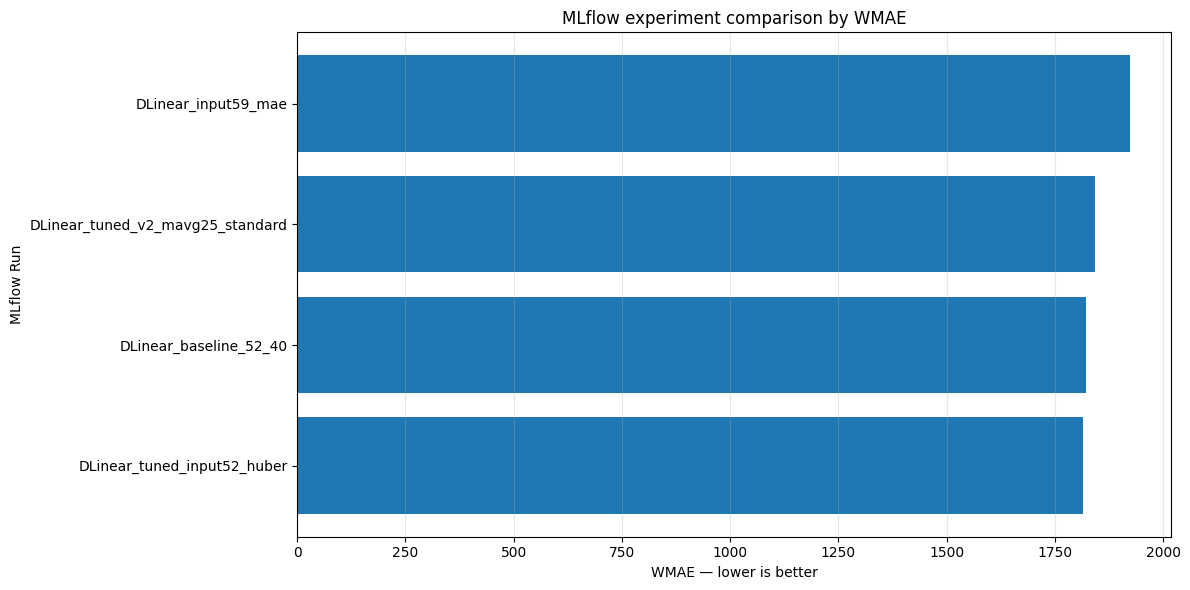

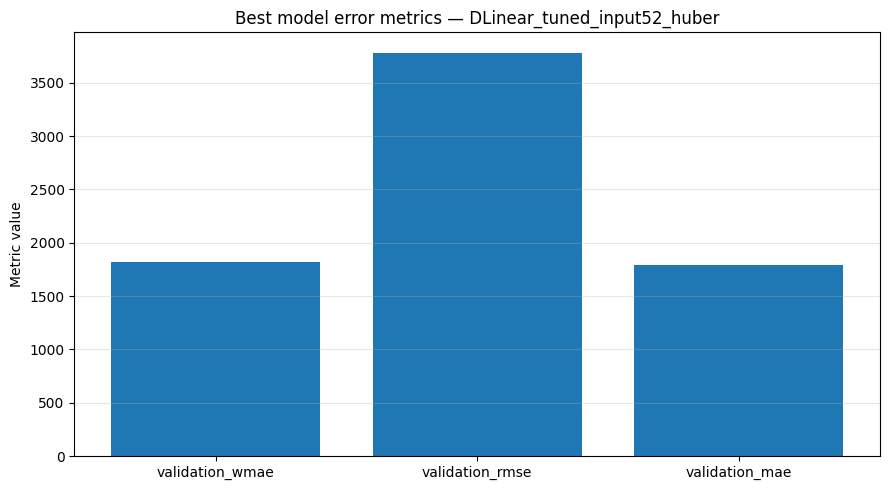

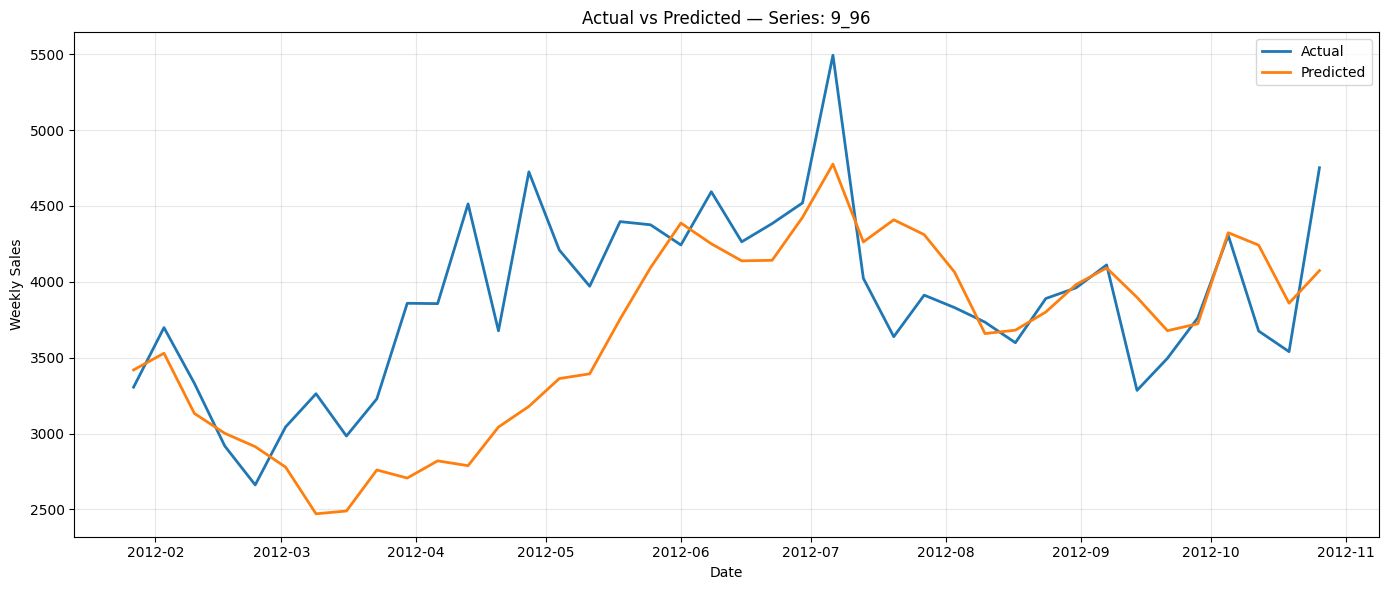

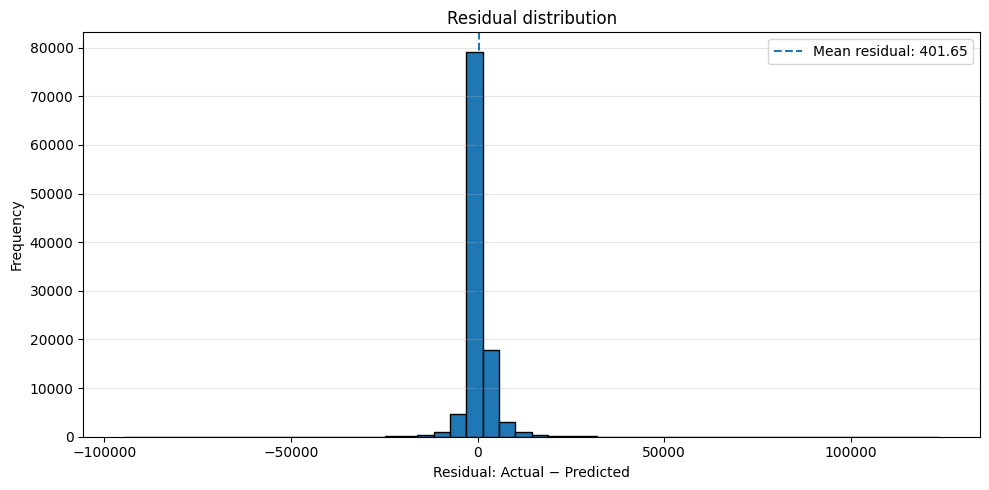

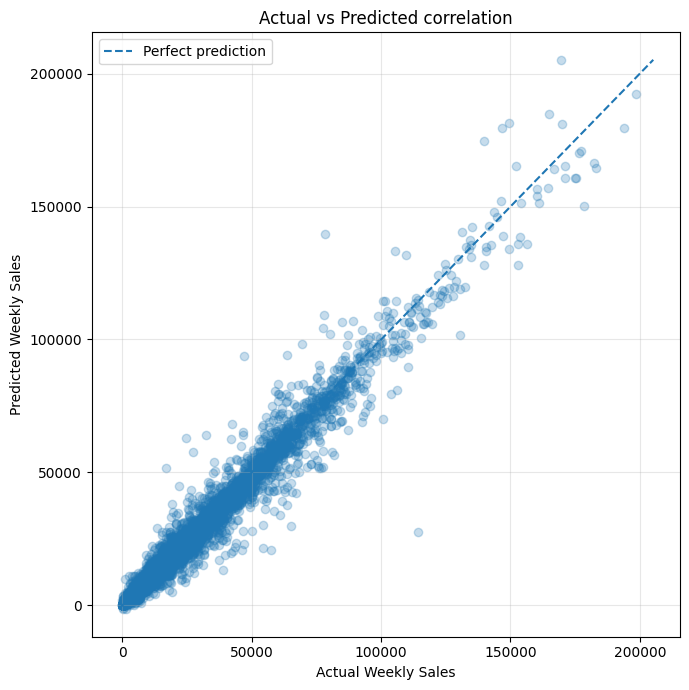


✅ Validation columns used: actual='y', prediction='DLinear'


In [63]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient
from IPython.display import display, HTML

client = MlflowClient()

# =========================================================
# 1. MLflow-დან საუკეთესო Run-ის მოძებნა
# =========================================================

runs = mlflow.search_runs(
    search_all_experiments=True,
    filter_string="attributes.status = 'FINISHED'"
)

if runs.empty:
    raise ValueError("MLflow-ში დასრულებული Run-ები ვერ მოიძებნა.")

# WMAE სვეტის ავტომატური მოძებნა
wmae_columns = [
    col for col in runs.columns
    if col.lower() in {
        "metrics.wmae",
        "metrics.val_wmae",
        "metrics.validation_wmae"
    }
]

if not wmae_columns:
    available_metrics = [
        col.replace("metrics.", "")
        for col in runs.columns
        if col.startswith("metrics.")
    ]
    raise ValueError(
        f"WMAE ვერ მოიძებნა. ხელმისაწვდომია: {available_metrics}"
    )

wmae_col = wmae_columns[0]

valid_runs = runs.dropna(subset=[wmae_col]).copy()
valid_runs = valid_runs.sort_values(wmae_col)

best_run = valid_runs.iloc[0]
run_id = best_run["run_id"]
experiment_id = best_run["experiment_id"]

run_name = best_run.get("tags.mlflow.runName", "Unnamed Run")
if pd.isna(run_name):
    run_name = "Unnamed Run"

tracking_uri = mlflow.get_tracking_uri().rstrip("/")
run_url = (
    f"{tracking_uri}/#/experiments/"
    f"{experiment_id}/runs/{run_id}"
)

# =========================================================
# 2. საუკეთესო მოდელის ინფორმაციის დაბეჭდვა
# =========================================================

print("=" * 75)
print("🏆 BEST MODEL FROM MLFLOW")
print("=" * 75)
print(f"Model / Run name : {run_name}")
print(f"Run ID           : {run_id}")
print(f"Experiment ID    : {experiment_id}")
print(f"Selection metric : {wmae_col.replace('metrics.', '')}")
print(f"Best WMAE        : {best_run[wmae_col]:,.4f}")

display(
    HTML(
        f'<a href="{run_url}" target="_blank">'
        f'🔗 Open best Run in MLflow / DagsHub</a>'
    )
)

print("\n📊 BEST MODEL METRICS")
print("-" * 75)

best_metrics = {}

for col in valid_runs.columns:
    if col.startswith("metrics.") and pd.notna(best_run.get(col)):
        metric_name = col.replace("metrics.", "")
        metric_value = float(best_run[col])
        best_metrics[metric_name] = metric_value
        print(f"{metric_name:<25}: {metric_value:,.6f}")

print("\n⚙️ BEST MODEL PARAMETERS")
print("-" * 75)

for col in valid_runs.columns:
    if col.startswith("params.") and pd.notna(best_run.get(col)):
        print(f"{col.replace('params.', ''):<25}: {best_run[col]}")

# =========================================================
# 3. გრაფიკი — MLflow Run-ების WMAE შედარება
# =========================================================

comparison = valid_runs.head(15).copy()

comparison["run_label"] = comparison["tags.mlflow.runName"].fillna(
    comparison["run_id"].str[:8]
)

comparison = comparison.sort_values(wmae_col, ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(
    comparison["run_label"],
    comparison[wmae_col]
)
plt.xlabel("WMAE — lower is better")
plt.ylabel("MLflow Run")
plt.title("MLflow experiment comparison by WMAE")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 4. გრაფიკი — საუკეთესო Run-ის მეტრიკები
# R² ცალკეა, რადგან მისი მასშტაბი განსხვავებულია
# =========================================================

error_metrics = {
    name: value
    for name, value in best_metrics.items()
    if name.lower() in {
        "wmae", "mae", "rmse",
        "val_wmae", "val_mae", "val_rmse",
        "validation_wmae", "validation_mae",
        "validation_rmse"
    }
}

if error_metrics:
    plt.figure(figsize=(9, 5))
    plt.bar(
        list(error_metrics.keys()),
        list(error_metrics.values())
    )
    plt.ylabel("Metric value")
    plt.title(f"Best model error metrics — {run_name}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# 5. Validation მონაცემებიდან Actual vs Predicted
# =========================================================

if "validation_plot_df" in globals():

    plot_df = validation_plot_df.copy()

    # რეალური მნიშვნელობის სვეტი
    actual_candidates = [
        col for col in ["y", "actual", "Weekly_Sales"]
        if col in plot_df.columns
    ]

    # პროგნოზის სვეტის მოძებნა
    excluded_cols = {
        "unique_id", "ds", "cutoff", "y",
        "actual", "Weekly_Sales", "IsHoliday"
    }

    prediction_candidates = [
        col for col in plot_df.columns
        if col not in excluded_cols
        and pd.api.types.is_numeric_dtype(plot_df[col])
    ]

    if actual_candidates and prediction_candidates:

        actual_col = actual_candidates[0]

        preferred_prediction_cols = [
            col for col in prediction_candidates
            if "dlinear" in col.lower()
        ]

        prediction_col = (
            preferred_prediction_cols[0]
            if preferred_prediction_cols
            else prediction_candidates[0]
        )

        plot_df = plot_df.dropna(
            subset=[actual_col, prediction_col]
        ).copy()

        # ერთი სერია — გრაფიკი უფრო მკაფიო რომ იყოს
        if "unique_id" in plot_df.columns:
            selected_id = (
                plot_df.groupby("unique_id")
                .size()
                .sort_values(ascending=False)
                .index[0]
            )

            series_df = plot_df[
                plot_df["unique_id"] == selected_id
            ].copy()

            series_title = f"Series: {selected_id}"
        else:
            series_df = plot_df.copy()
            series_title = "Validation sample"

        if "ds" in series_df.columns:
            series_df["ds"] = pd.to_datetime(series_df["ds"])
            series_df = series_df.sort_values("ds")
            x_values = series_df["ds"]
            x_label = "Date"
        else:
            series_df = series_df.reset_index(drop=True)
            x_values = series_df.index
            x_label = "Observation"

        # Actual vs Predicted
        plt.figure(figsize=(14, 6))
        plt.plot(
            x_values,
            series_df[actual_col],
            label="Actual",
            linewidth=2
        )
        plt.plot(
            x_values,
            series_df[prediction_col],
            label="Predicted",
            linewidth=2
        )
        plt.xlabel(x_label)
        plt.ylabel("Weekly Sales")
        plt.title(
            f"Actual vs Predicted — {series_title}"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Residual histogram
        residuals = (
            plot_df[actual_col] -
            plot_df[prediction_col]
        )

        plt.figure(figsize=(10, 5))
        plt.hist(residuals, bins=50, edgecolor="black")
        plt.axvline(
            residuals.mean(),
            linestyle="--",
            label=f"Mean residual: {residuals.mean():,.2f}"
        )
        plt.xlabel("Residual: Actual − Predicted")
        plt.ylabel("Frequency")
        plt.title("Residual distribution")
        plt.legend()
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Actual vs Predicted scatter
        sample_size = min(10000, len(plot_df))
        scatter_df = plot_df.sample(
            sample_size,
            random_state=42
        )

        minimum = min(
            scatter_df[actual_col].min(),
            scatter_df[prediction_col].min()
        )

        maximum = max(
            scatter_df[actual_col].max(),
            scatter_df[prediction_col].max()
        )

        plt.figure(figsize=(7, 7))
        plt.scatter(
            scatter_df[actual_col],
            scatter_df[prediction_col],
            alpha=0.25
        )
        plt.plot(
            [minimum, maximum],
            [minimum, maximum],
            linestyle="--",
            label="Perfect prediction"
        )
        plt.xlabel("Actual Weekly Sales")
        plt.ylabel("Predicted Weekly Sales")
        plt.title("Actual vs Predicted correlation")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(
            f"\n✅ Validation columns used: "
            f"actual='{actual_col}', "
            f"prediction='{prediction_col}'"
        )

    else:
        print(
            "\n⚠️ validation_plot_df-ში Actual ან "
            "Prediction სვეტი ვერ მოიძებნა."
        )

else:
    print(
        "\n⚠️ validation_plot_df არ არსებობს — "
        "MLflow შედარების გრაფიკები მაინც აიგო."
    )